In [47]:
# ============================================================
# LCA-Emissionsberechnung auf Basis gespeicherter Flottenmodell-Ergebnisse
# ============================================================

import pandas as pd
import json
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt


# ============================================================
# 1. Zentraler Parameterblock
# ============================================================

RESULTS_DIR = Path("Results")
CONFIG_PATH = Path("fleet_model_config.json")
config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))

NEW_VEHICLES_PATH = RESULTS_DIR / "policy_new_vehicles_all.csv"
FINAL_STOCK_PATH = RESULTS_DIR / "policy_final_stock_all.csv"
EXITS_PATH = RESULTS_DIR / "policy_exits_all.csv"
HISTORICAL_EXITS_PATH = Path("../Data/321-140-17133-26-ABS.csv")

# Pfad zur separaten Emissionsparameterdatei einfach hier anpassen
EMISSION_PARAMS_PATH = Path("LCA_Emissions_Python.csv")

# Zentrale Annahmen
ANNUAL_KM_PER_VEHICLE = 12_500
ANALYSIS_START_YEAR = 2025
ANALYSIS_END_YEAR = 2050

# Zeitliche Zuordnung der Emissionen
PRODUCTION_YEAR_OFFSET = -1   # Produktionsemissionen: Jahr der Erstzulassung - 1
USE_YEAR_OFFSET = 0           # Nutzungsemissionen: Jahr
EOL_YEAR_OFFSET = 1           # End-of-Life-Emissionen: Jahr + 1

# CSV-Einstellungen
CSV_SEP = ";"
CSV_ENCODING = "utf-8-sig"

# Output-Dateien
OUT_PREPARED_NEW_VEHICLES = RESULTS_DIR / "prepared_new_vehicles_lca.csv"
OUT_PREPARED_FINAL_STOCK = RESULTS_DIR / "prepared_final_stock_lca.csv"
OUT_PREPARED_EXITS = RESULTS_DIR / "prepared_exits_lca.csv"

OUT_EMISSIONS_BY_PHASE = RESULTS_DIR / "emissions_by_phase.csv"
OUT_SUMMARY_YEAR_PHASE = RESULTS_DIR / "emissions_summary_by_year_phase.csv"
OUT_SUMMARY_YEAR_TOTAL = RESULTS_DIR / "emissions_summary_by_year_total.csv"
OUT_SUMMARY_TOTAL_SCENARIO = RESULTS_DIR / "emissions_summary_total_by_scenario.csv"


# ============================================================
# 2. Mapping-Definitionen
# ============================================================

SEGMENT_TO_SIZE_CLASS = {
    "Minis": "Small",
    "Kleinwagen": "Small",

    "Kompaktklasse": "Medium",
    "Mittelklasse": "Medium",
    "Mini-Vans": "Medium",
    "Sonstige": "Medium",

    "Obere Mittelklasse": "Large",
    "Oberklasse": "Large",
    "SUVs": "Large",
    "Geländewagen": "Large",
    "Sportwagen": "Large",
    "Großraum-Vans": "Large",
    "Utilities": "Large",
    "Wohnmobile": "Large",
}

ANTRIEBSART_TO_DRIVETRAIN_GROUP = {
    "Elektro (BEV)": "BEV",
    "Benzin": "ICE_Petrol",
    "Diesel": "ICE_Diesel",
    "Hybrid": "ICE_Petrol",
    "Erdgas (CNG) (einschl. bivalent)": "ICE_Petrol",
    "Flüssiggas (LPG) (einschl. bivalent)": "ICE_Petrol",
    "Sonstige": "ICE_Petrol",
}

PARAM_DRIVETRAIN_STANDARDIZATION = {
    "BEV": "BEV",
    "ICEVs-Petrol": "ICE_Petrol",
    "ICEVs-Diesel": "ICE_Diesel",
}


# ============================================================
# 3. Hilfsfunktionen
# ============================================================

def read_semicolon_csv(path: Path) -> pd.DataFrame:
    """
    Lädt eine CSV-Datei mit Semikolon-Trennzeichen und utf-8-sig-Encoding.
    """
    if not path.exists():
        raise FileNotFoundError(f"Datei nicht gefunden: {path}")

    return pd.read_csv(
        path,
        sep=CSV_SEP,
        encoding=CSV_ENCODING,
    )


def parse_german_numeric_series(series: pd.Series) -> pd.Series:
    """
    Wandelt numerische Spalten robust in float um.

    Unterstützt u. a.:
    - deutsche Dezimalkommas: 5,00
    - deutsche Tausenderpunkte: 1.234,56
    - normale Punkte: 1234.56
    - bereits numerische Werte
    """
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(float)

    s = (
        series.astype(str)
        .str.strip()
        .replace({"": np.nan, "nan": np.nan, "None": np.nan})
    )

    def convert_value(x):
        if pd.isna(x):
            return np.nan

        x = str(x).strip()

        # Wenn ein Komma enthalten ist, interpretieren wir es als deutsches Dezimalzeichen.
        if "," in x:
            x = x.replace(".", "")
            x = x.replace(",", ".")

        return pd.to_numeric(x, errors="coerce")

    return s.apply(convert_value).astype(float)


def require_columns(df: pd.DataFrame, required_columns: list[str], df_name: str) -> None:
    """
    Prüft, ob alle benötigten Spalten vorhanden sind.
    """
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError(
            f"In Tabelle '{df_name}' fehlen folgende Spalten: {missing}\n"
            f"Vorhandene Spalten: {list(df.columns)}"
        )


def add_lca_mapping_columns(df: pd.DataFrame, df_name: str) -> pd.DataFrame:
    """
    Ergänzt Flottentabellen um:
    - size_class
    - drivetrain_group_std
    """
    df = df.copy()

    require_columns(df, ["Segment", "Antriebsart"], df_name)

    df["size_class"] = df["Segment"].map(SEGMENT_TO_SIZE_CLASS)
    df["drivetrain_group_std"] = df["Antriebsart"].map(ANTRIEBSART_TO_DRIVETRAIN_GROUP)

    missing_size = df.loc[df["size_class"].isna(), "Segment"].dropna().unique()
    missing_drive = df.loc[df["drivetrain_group_std"].isna(), "Antriebsart"].dropna().unique()

    if len(missing_size) > 0:
        print(
            f"Warnung: Für folgende Segmente in '{df_name}' fehlt ein size_class-Mapping. "
            f"Diese Zeilen können später keine Emissionsparameter erhalten:\n{missing_size}"
        )

    if len(missing_drive) > 0:
        print(
            f"Warnung: Für folgende Antriebsarten in '{df_name}' fehlt ein drivetrain_group_std-Mapping. "
            f"Diese Zeilen können später keine Emissionsparameter erhalten:\n{missing_drive}"
        )

    return df


def load_emission_parameters(path: Path) -> pd.DataFrame:
    """
    Lädt die Emissionsparameter im breiten Format, bereinigt numerische Werte
    und bringt sie in ein langes Format.

    Ergebnis enthält:
    - Parameter
    - vehicle_type_raw
    - value
    - drivetrain_group_raw
    - drivetrain_group_std
    - size_class
    """
    params_wide = read_semicolon_csv(path)

    require_columns(
        params_wide,
        ["Parameter", "Explanation_parameter"],
        "LCA_Emissions_Python.csv"
    )

    id_cols = ["Parameter", "Explanation_parameter"]
    value_cols = [col for col in params_wide.columns if col not in id_cols]

    params_long = params_wide.melt(
        id_vars=id_cols,
        value_vars=value_cols,
        var_name="vehicle_type_raw",
        value_name="value_raw",
    )

    params_long["value"] = parse_german_numeric_series(params_long["value_raw"])

    # Kombinationen wie BEV_small oder ICEVs-Diesel_large trennen
    split_cols = params_long["vehicle_type_raw"].str.rsplit("_", n=1, expand=True)
    params_long["drivetrain_group_raw"] = split_cols[0]
    params_long["size_class_raw"] = split_cols[1]

    params_long["drivetrain_group_std"] = params_long["drivetrain_group_raw"].map(
        PARAM_DRIVETRAIN_STANDARDIZATION
    )

    params_long["size_class"] = (
        params_long["size_class_raw"]
        .str.strip()
        .str.lower()
        .map({
            "small": "Small",
            "medium": "Medium",
            "large": "Large",
        })
    )

    missing_drive = params_long.loc[
        params_long["drivetrain_group_std"].isna(),
        "drivetrain_group_raw"
    ].dropna().unique()

    missing_size = params_long.loc[
        params_long["size_class"].isna(),
        "size_class_raw"
    ].dropna().unique()

    if len(missing_drive) > 0:
        print(
            "Warnung: Für folgende Emissionsparameter-Antriebsgruppen fehlt eine Standardisierung:\n"
            f"{missing_drive}"
        )

    if len(missing_size) > 0:
        print(
            "Warnung: Für folgende Emissionsparameter-Größenklassen fehlt eine Standardisierung:\n"
            f"{missing_size}"
        )

    return params_long


def create_parameter_lookup(params_long: pd.DataFrame) -> pd.DataFrame:
    """
    Erzeugt eine breite Lookup-Tabelle mit je einer Zeile pro
    drivetrain_group_std / size_class und je einer Spalte pro Parameter.
    """
    lookup = (
        params_long
        .pivot_table(
            index=["drivetrain_group_std", "size_class"],
            columns="Parameter",
            values="value",
            aggfunc="first",
        )
        .reset_index()
    )

    lookup.columns.name = None
    return lookup


def merge_params(
    df: pd.DataFrame,
    params_lookup: pd.DataFrame,
    required_params: list[str],
    df_name: str,
) -> pd.DataFrame:
    """
    Verknüpft Fahrzeugdaten mit Emissionsparametern.

    Fehlende Parameterwerte werden mit 0.0 ersetzt und als Warnung ausgegeben.
    """
    df = df.copy()

    df = df.merge(
        params_lookup,
        on=["drivetrain_group_std", "size_class"],
        how="left",
    )

    for param in required_params:
        if param not in df.columns:
            print(
                f"Warnung: Parameter '{param}' ist in der Emissionsparameterdatei nicht vorhanden. "
                f"Er wird in '{df_name}' mit 0.0 angesetzt."
            )
            df[param] = 0.0
        else:
            missing_count = df[param].isna().sum()
            if missing_count > 0:
                print(
                    f"Warnung: In '{df_name}' fehlen {missing_count} Werte für Parameter '{param}'. "
                    f"Fehlende Werte werden mit 0.0 ersetzt."
                )
                df[param] = df[param].fillna(0.0)

    return df


def ensure_numeric_column(df: pd.DataFrame, column: str, df_name: str) -> pd.DataFrame:
    """
    Wandelt eine Spalte in numerische Werte um.
    """
    df = df.copy()

    if column not in df.columns:
        raise ValueError(
            f"In Tabelle '{df_name}' fehlt die benötigte Spalte '{column}'. "
            f"Vorhandene Spalten: {list(df.columns)}"
        )

    df[column] = parse_german_numeric_series(df[column]).fillna(0.0)
    return df


def get_registration_year_column(df: pd.DataFrame) -> str | None:
    """
    Gibt die Spalte für das Jahr der Erstzulassung zurück, falls vorhanden.
    """
    candidates = [
        "Jahr der Erstzulassung",
        "Jahr_der_Erstzulassung",
        "Erstzulassungsjahr",
    ]

    for col in candidates:
        if col in df.columns:
            return col

    return None


# ============================================================
# 4. Input-Daten laden
# ============================================================

new_vehicles = read_semicolon_csv(NEW_VEHICLES_PATH)
final_stock = read_semicolon_csv(FINAL_STOCK_PATH)
exits = read_semicolon_csv(EXITS_PATH)
historical_exits = pd.read_csv(HISTORICAL_EXITS_PATH, sep=CSV_SEP, encoding="latin1")

emission_params_long = load_emission_parameters(EMISSION_PARAMS_PATH)
emission_params_lookup = create_parameter_lookup(emission_params_long)

print("Geladene Tabellen:")
print(f"- new_vehicles: {new_vehicles.shape}")
print(f"- final_stock:  {final_stock.shape}")
print(f"- exits:        {exits.shape}")
print(f"- historical_exits: {historical_exits.shape}")
print(f"- emission_params_long: {emission_params_long.shape}")
print(f"- emission_params_lookup: {emission_params_lookup.shape}")


# ============================================================
# 5. Flottentabellen vorbereiten und speichern
# ============================================================

new_vehicles_prepared = add_lca_mapping_columns(new_vehicles, "policy_new_vehicles_all.csv")
final_stock_prepared = add_lca_mapping_columns(final_stock, "policy_final_stock_all.csv")
exits_prepared = add_lca_mapping_columns(exits, "policy_exits_all.csv")

new_vehicles_prepared.to_csv(
    OUT_PREPARED_NEW_VEHICLES,
    sep=CSV_SEP,
    encoding=CSV_ENCODING,
    index=False,
)

final_stock_prepared.to_csv(
    OUT_PREPARED_FINAL_STOCK,
    sep=CSV_SEP,
    encoding=CSV_ENCODING,
    index=False,
)

exits_prepared.to_csv(
    OUT_PREPARED_EXITS,
    sep=CSV_SEP,
    encoding=CSV_ENCODING,
    index=False,
)

print("Vorbereitete LCA-Flottentabellen gespeichert:")
print(f"- {OUT_PREPARED_NEW_VEHICLES}")
print(f"- {OUT_PREPARED_FINAL_STOCK}")
print(f"- {OUT_PREPARED_EXITS}")


# ============================================================
# 6. Produktionsemissionen berechnen
# ============================================================

require_columns(
    new_vehicles_prepared,
    ["Szenario", "Jahr", "Segment", "Antriebsart", "neue_fahrzeuge"],
    "prepared_new_vehicles_lca.csv",
)

prod = ensure_numeric_column(
    new_vehicles_prepared,
    "neue_fahrzeuge",
    "prepared_new_vehicles_lca.csv",
)

prod = merge_params(
    prod,
    emission_params_lookup,
    required_params=["Vehicle_production"],
    df_name="production",
)

registration_year_col = get_registration_year_column(prod)

if registration_year_col is not None:
    prod["emission_year"] = parse_german_numeric_series(prod[registration_year_col]) + PRODUCTION_YEAR_OFFSET
else:
    print(
        "Hinweis: Spalte 'Jahr der Erstzulassung' fehlt. "
        "Für Produktionsemissionen wird ersatzweise Jahr - 1 verwendet."
    )
    prod["emission_year"] = parse_german_numeric_series(prod["Jahr"]) + PRODUCTION_YEAR_OFFSET

prod["phase"] = "production"
prod["vehicles"] = prod["neue_fahrzeuge"]
prod["emissions_tco2e"] = prod["neue_fahrzeuge"] * prod["Vehicle_production"]

production_emissions = prod[
    [
        "Szenario",
        "emission_year",
        "phase",
        "Segment",
        "Antriebsart",
        "drivetrain_group_std",
        "size_class",
        "vehicles",
        "emissions_tco2e",
    ]
].copy()

# BEVs und Hybride verwenden die BEV-Batterieparameter ihrer Größenklasse.
# Hybride behalten für alle anderen Parameter ihr ICE_Petrol-Mapping.
# kgCO2e/kWh * kWh / 1.000 = tCO2e pro Fahrzeug.
battery_vehicle = (
    prod["drivetrain_group_std"].eq("BEV")
    | prod["Antriebsart"].eq("Hybrid")
)
required_battery_params = ["Battery_production", "Battery_capacity"]
missing_battery_columns = [
    name for name in required_battery_params if name not in emission_params_lookup.columns
]
if missing_battery_columns and battery_vehicle.any():
    raise ValueError(
        f"LCA-Daten enthalten keine BEV-Batterieparameter: {missing_battery_columns}"
    )

battery_lookup = (
    emission_params_lookup.loc[
        emission_params_lookup["drivetrain_group_std"].eq("BEV"),
        ["size_class", *required_battery_params],
    ]
    .rename(columns={name: f"bev_{name}" for name in required_battery_params})
)
prod = prod.merge(battery_lookup, on="size_class", how="left", validate="many_to_one")
battery_vehicle = (
    prod["drivetrain_group_std"].eq("BEV")
    | prod["Antriebsart"].eq("Hybrid")
)
bev_battery_params = [f"bev_{name}" for name in required_battery_params]
missing_battery_params = prod.loc[battery_vehicle, bev_battery_params].isna().any(axis=1)
if missing_battery_params.any():
    missing_types = (
        prod.loc[battery_vehicle & missing_battery_params, ["Antriebsart", "size_class"]]
        .drop_duplicates().to_dict("records")
    )
    raise ValueError(
        f"Fehlende BEV-Batterieparameter für BEVs/Hybride: {missing_types}"
    )

battery_prod = prod.copy()
battery_prod["phase"] = "battery_production"
battery_prod["emissions_tco2e"] = np.where(
    battery_vehicle,
    battery_prod["neue_fahrzeuge"]
    * battery_prod["bev_Battery_production"]
    * battery_prod["bev_Battery_capacity"]
    / 1_000.0,
    0.0,
)
battery_production_emissions = battery_prod[
    [
        "Szenario", "emission_year", "phase", "Segment",
        "Antriebsart", "drivetrain_group_std", "size_class",
        "vehicles", "emissions_tco2e",
    ]
].copy()


# ============================================================
# 7. Nutzungsemissionen berechnen
# ============================================================

require_columns(
    final_stock_prepared,
    ["Szenario", "Jahr", "Segment", "Antriebsart", "finaler_bestand"],
    "prepared_final_stock_lca.csv",
)

use = ensure_numeric_column(
    final_stock_prepared,
    "finaler_bestand",
    "prepared_final_stock_lca.csv",
)

use = merge_params(
    use,
    emission_params_lookup,
    required_params=[
        "Consumption",
        "WTT",
        "TTW",
        "Maintenance in gCO2e/km",
    ],
    df_name="use",
)

use["emission_year"] = parse_german_numeric_series(use["Jahr"]) + USE_YEAR_OFFSET
use["phase"] = "use"
use["vehicles"] = use["finaler_bestand"]

electricity_mix_path = {
    int(year): float(value)
    for year, value in config["ghg"]["electricity_mix_gco2e_per_kwh"].items()
}
required_electricity_years = set(range(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR + 1))
missing_electricity_years = sorted(required_electricity_years.difference(electricity_mix_path))
if missing_electricity_years:
    raise ValueError(f"Im Strommixpfad fehlen Jahre: {missing_electricity_years}")
use["electricity_mix_gco2e_per_kwh"] = use["emission_year"].map(electricity_mix_path)

# gCO2e/km für Nutzung
# BEV:
#   Consumption = kWh/100 km
#   electricity_mix_gco2e_per_kwh = jahresspezifische gCO2e/kWh aus der Config
#
# Benzin / Diesel:
#   Consumption = Liter/100 km
#   WTT und TTW = gCO2e/Liter
#
# Maintenance wird in beiden Fällen direkt als gCO2e/km addiert.

is_bev = use["drivetrain_group_std"].eq("BEV")

use["use_emissions_gco2e_per_km"] = np.where(
    is_bev,
    (use["Consumption"] / 100.0) * use["electricity_mix_gco2e_per_kwh"]
    + use["Maintenance in gCO2e/km"],
    (use["Consumption"] / 100.0) * (use["WTT"] + use["TTW"])
    + use["Maintenance in gCO2e/km"],
)

# Umrechnung:
# Fahrzeuge * km/Jahr * gCO2e/km = gCO2e
# gCO2e / 1_000_000 = tCO2e
use["emissions_tco2e"] = (
    use["finaler_bestand"]
    * ANNUAL_KM_PER_VEHICLE
    * use["use_emissions_gco2e_per_km"]
    / 1_000_000.0
)

use_emissions = use[
    [
        "Szenario",
        "emission_year",
        "phase",
        "Segment",
        "Antriebsart",
        "drivetrain_group_std",
        "size_class",
        "vehicles",
        "emissions_tco2e",
    ]
].copy()


# ============================================================
# 8. End-of-Life-Emissionen berechnen
# ============================================================

require_columns(
    exits_prepared,
    ["Szenario", "Jahr", "Segment", "Antriebsart", "exits"],
    "prepared_exits_lca.csv",
)

eol = ensure_numeric_column(
    exits_prepared,
    "exits",
    "prepared_exits_lca.csv",
)

eol = merge_params(
    eol,
    emission_params_lookup,
    required_params=["End_of_life"],
    df_name="end_of_life",
)

eol["emission_year"] = parse_german_numeric_series(eol["Jahr"]) + EOL_YEAR_OFFSET
eol["phase"] = "end_of_life"
eol["vehicles"] = eol["exits"]
eol["emissions_tco2e"] = eol["exits"] * eol["End_of_life"]

eol_emissions = eol[
    [
        "Szenario",
        "emission_year",
        "phase",
        "Segment",
        "Antriebsart",
        "drivetrain_group_std",
        "size_class",
        "vehicles",
        "emissions_tco2e",
    ]
].copy()

# Historische ABS schließen den Beginn der EoL-Zeitreihe:
# ABS 2024 -> EoL 2025 und ABS 2025 -> EoL 2026.
# Ab ABS/Exit 2026 stammen die Werte aus dem Flottenmodell und erscheinen 2027.
historical_eol = historical_exits.loc[
    historical_exits["Berichtsjahr"].isin([2024, 2025]),
    ["Berichtsjahr", "Segment", "Antriebsart", "Anzahl"],
].copy()
historical_eol = add_lca_mapping_columns(historical_eol, "historische ABS 2024/2025")
historical_eol = historical_eol.rename(columns={"Anzahl": "exits"})
historical_eol = ensure_numeric_column(historical_eol, "exits", "historische ABS 2024/2025")
historical_eol = merge_params(
    historical_eol, emission_params_lookup, required_params=["End_of_life"],
    df_name="historical_end_of_life",
)
historical_eol["emission_year"] = historical_eol["Berichtsjahr"] + EOL_YEAR_OFFSET
historical_eol["phase"] = "end_of_life"
historical_eol["vehicles"] = historical_eol["exits"]
historical_eol["emissions_tco2e"] = historical_eol["exits"] * historical_eol["End_of_life"]
scenario_names = pd.DataFrame({"Szenario": sorted(final_stock_prepared["Szenario"].unique())})
historical_eol = historical_eol.merge(scenario_names, how="cross")
historical_eol_emissions = historical_eol[
    ["Szenario", "emission_year", "phase", "Segment", "Antriebsart",
     "drivetrain_group_std", "size_class", "vehicles", "emissions_tco2e"]
].copy()
eol_emissions = pd.concat([historical_eol_emissions, eol_emissions], ignore_index=True)


# ============================================================
# 9. Gemeinsame Ergebnistabelle emissions_by_phase
# ============================================================

emissions_by_phase = pd.concat(
    [
        production_emissions,
        battery_production_emissions,
        use_emissions,
        eol_emissions,
    ],
    ignore_index=True,
)

emissions_by_phase["emission_year"] = emissions_by_phase["emission_year"].astype(int)
emissions_by_phase["vehicles"] = emissions_by_phase["vehicles"].fillna(0.0)
emissions_by_phase["emissions_tco2e"] = emissions_by_phase["emissions_tco2e"].fillna(0.0)

# Das Flottenmodell läuft bis 2051, damit dessen Produktion im Jahr 2050
# bilanziert werden kann. Die veröffentlichte GHG-Zeitreihe endet bei 2050.
emissions_by_phase = emissions_by_phase.loc[
    emissions_by_phase["emission_year"].between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
].copy()

emissions_by_phase = emissions_by_phase.sort_values(
    [
        "Szenario",
        "emission_year",
        "phase",
        "Segment",
        "Antriebsart",
    ]
).reset_index(drop=True)

emissions_by_phase.head()

Geladene Tabellen:
- new_vehicles: (8424, 11)
- final_stock:  (355759, 7)
- exits:        (339819, 8)
- historical_exits: (21219, 5)
- emission_params_long: (81, 9)
- emission_params_lookup: (9, 11)
Vorbereitete LCA-Flottentabellen gespeichert:
- Results\prepared_new_vehicles_lca.csv
- Results\prepared_final_stock_lca.csv
- Results\prepared_exits_lca.csv
Warnung: In 'use' fehlen 73926 Werte für Parameter 'WTT'. Fehlende Werte werden mit 0.0 ersetzt.
Warnung: In 'use' fehlen 73926 Werte für Parameter 'TTW'. Fehlende Werte werden mit 0.0 ersetzt.
Warnung: Parameter 'Maintenance in gCO2e/km' ist in der Emissionsparameterdatei nicht vorhanden. Er wird in 'use' mit 0.0 angesetzt.


,Szenario,emission_year,phase,Segment,Antriebsart,drivetrain_group_std,size_class,vehicles,emissions_tco2e
0,abwrackpraemie,2025,battery_production,Geländewagen,Benzin,ICE_Petrol,Large,26818.709740,0.000000e+00
1,abwrackpraemie,2025,battery_production,Geländewagen,Diesel,ICE_Diesel,Large,48195.555535,0.000000e+00
2,abwrackpraemie,2025,battery_production,Geländewagen,Elektro (BEV),BEV,Large,13307.915006,1.077941e+05
3,abwrackpraemie,2025,battery_production,Geländewagen,Hybrid,ICE_Petrol,Large,209898.561009,1.700178e+06
4,abwrackpraemie,2025,battery_production,Großraum-Vans,Benzin,ICE_Petrol,Large,12594.790151,0.000000e+00


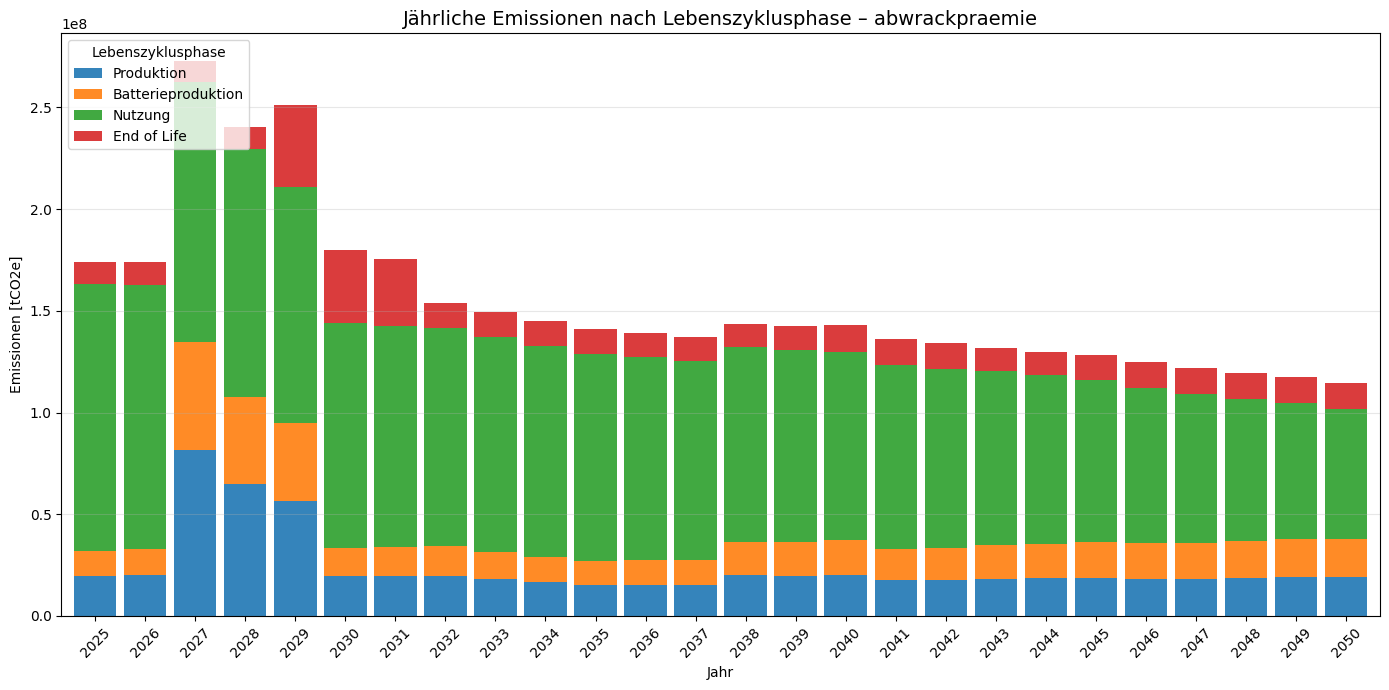

Diagramm gespeichert: Results\emissions_area_abwrackpraemie.png


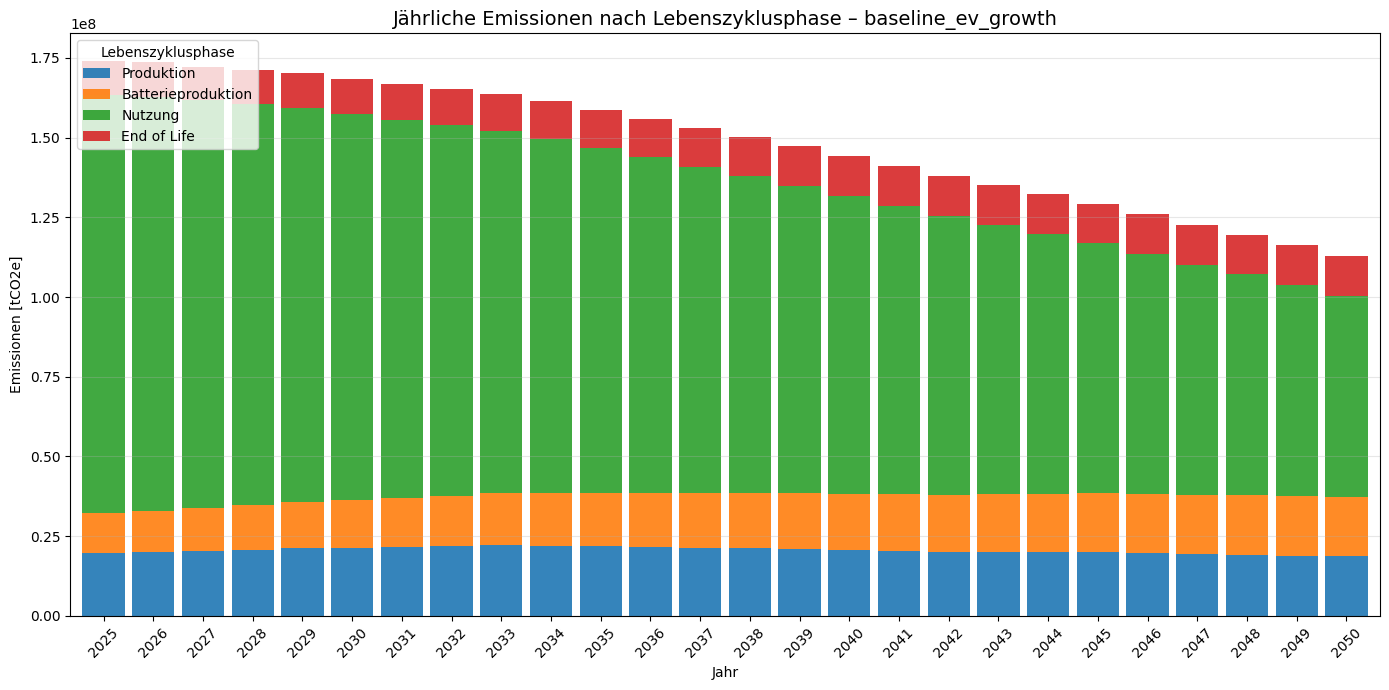

Diagramm gespeichert: Results\emissions_area_baseline_ev_growth.png


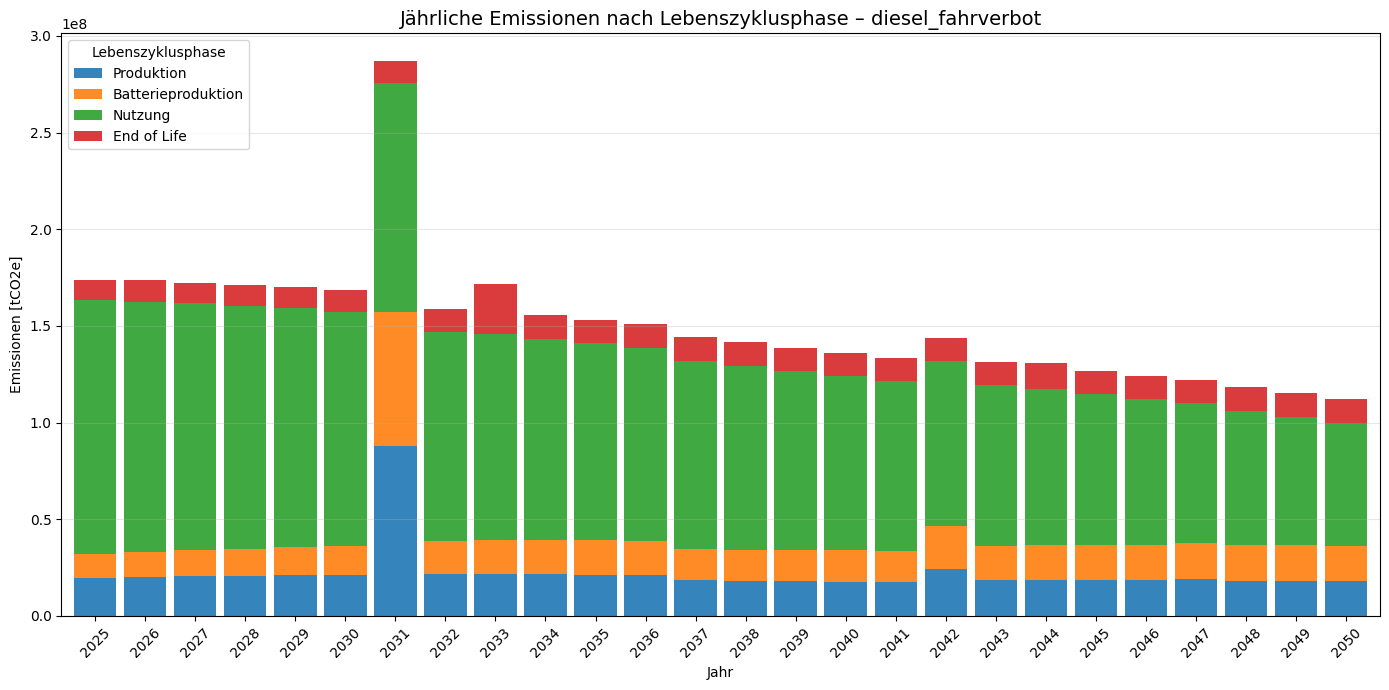

Diagramm gespeichert: Results\emissions_area_diesel_fahrverbot.png


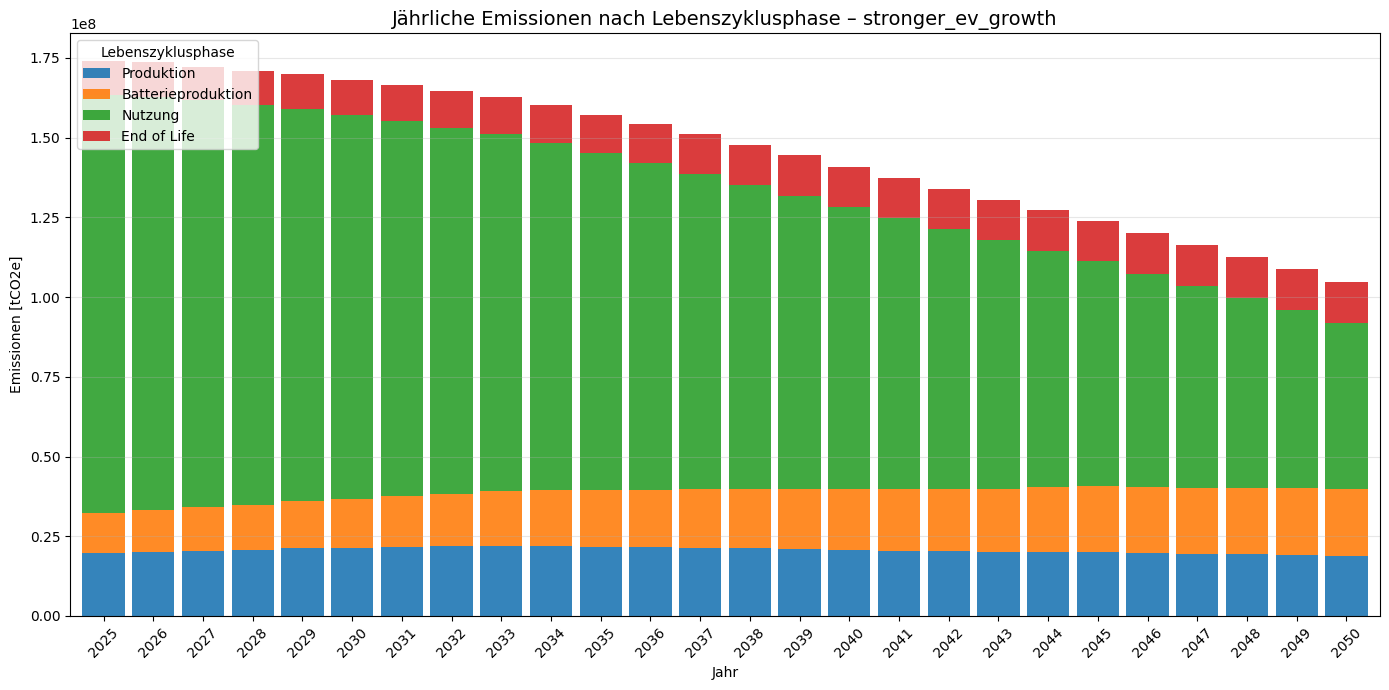

Diagramm gespeichert: Results\emissions_area_stronger_ev_growth.png


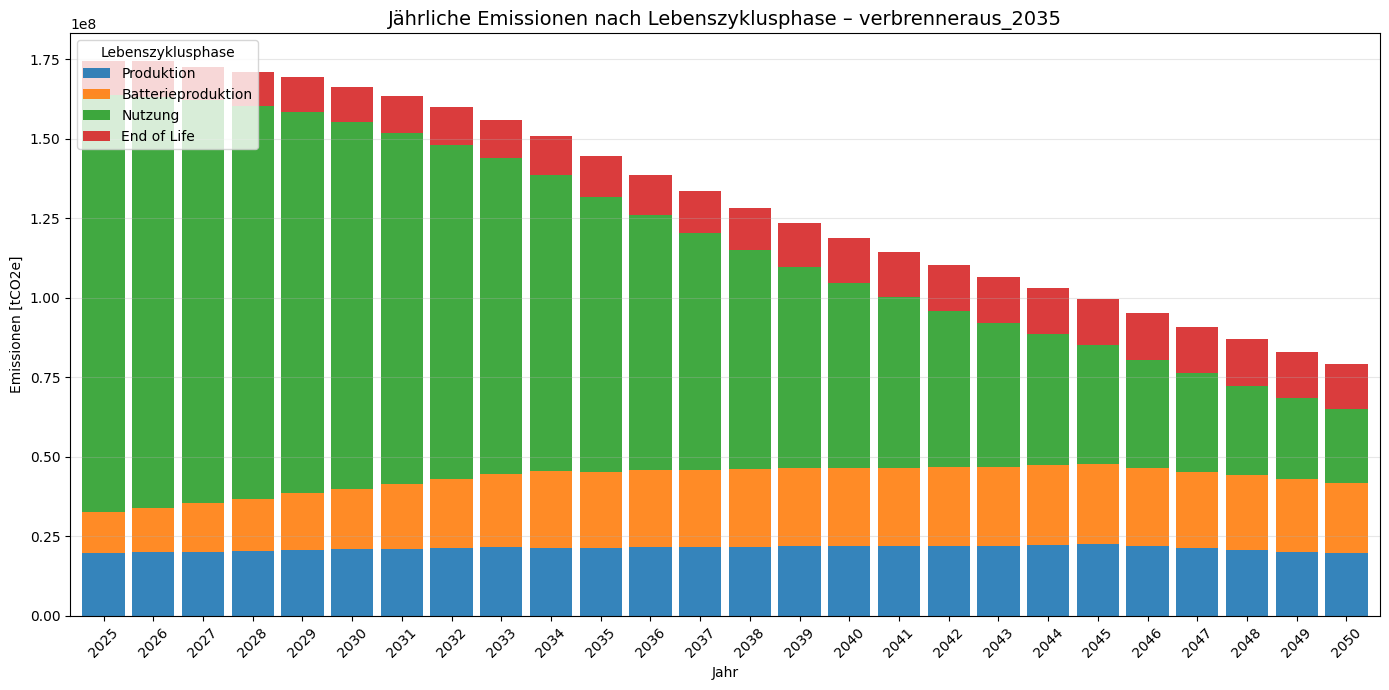

Diagramm gespeichert: Results\emissions_area_verbrenneraus_2035.png


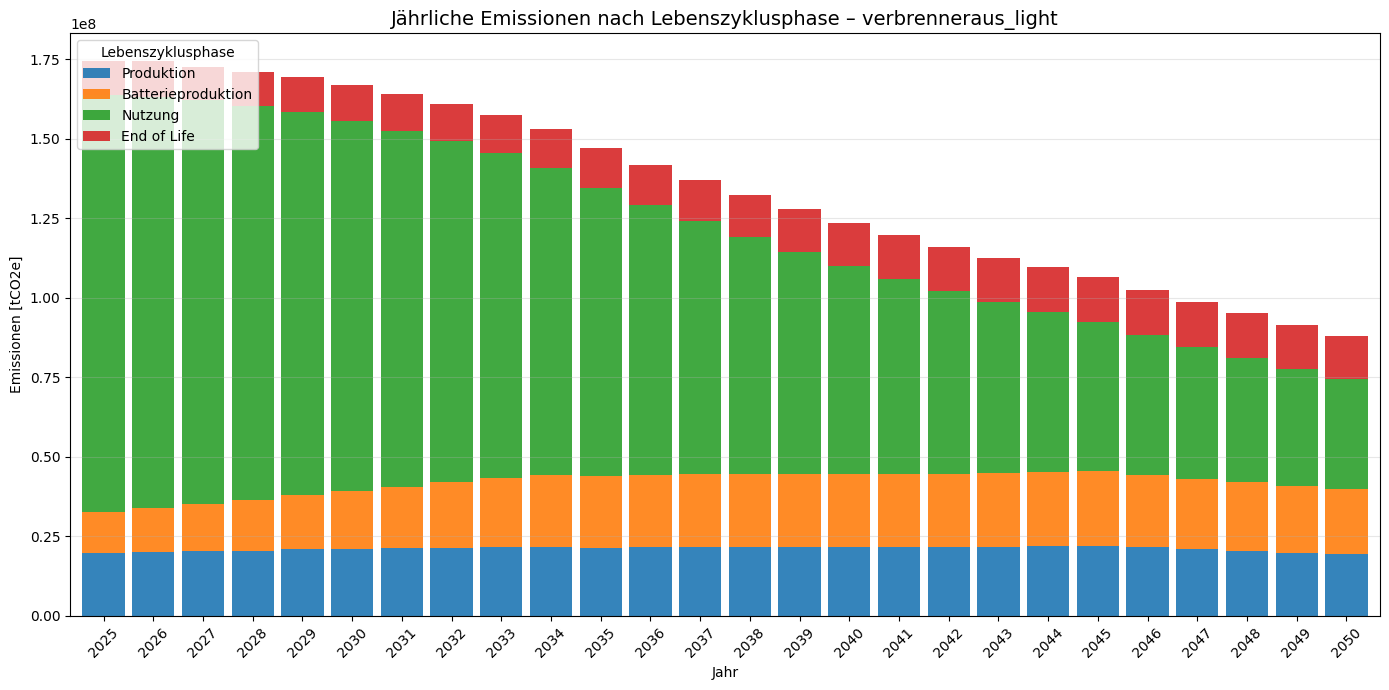

Diagramm gespeichert: Results\emissions_area_verbrenneraus_light.png


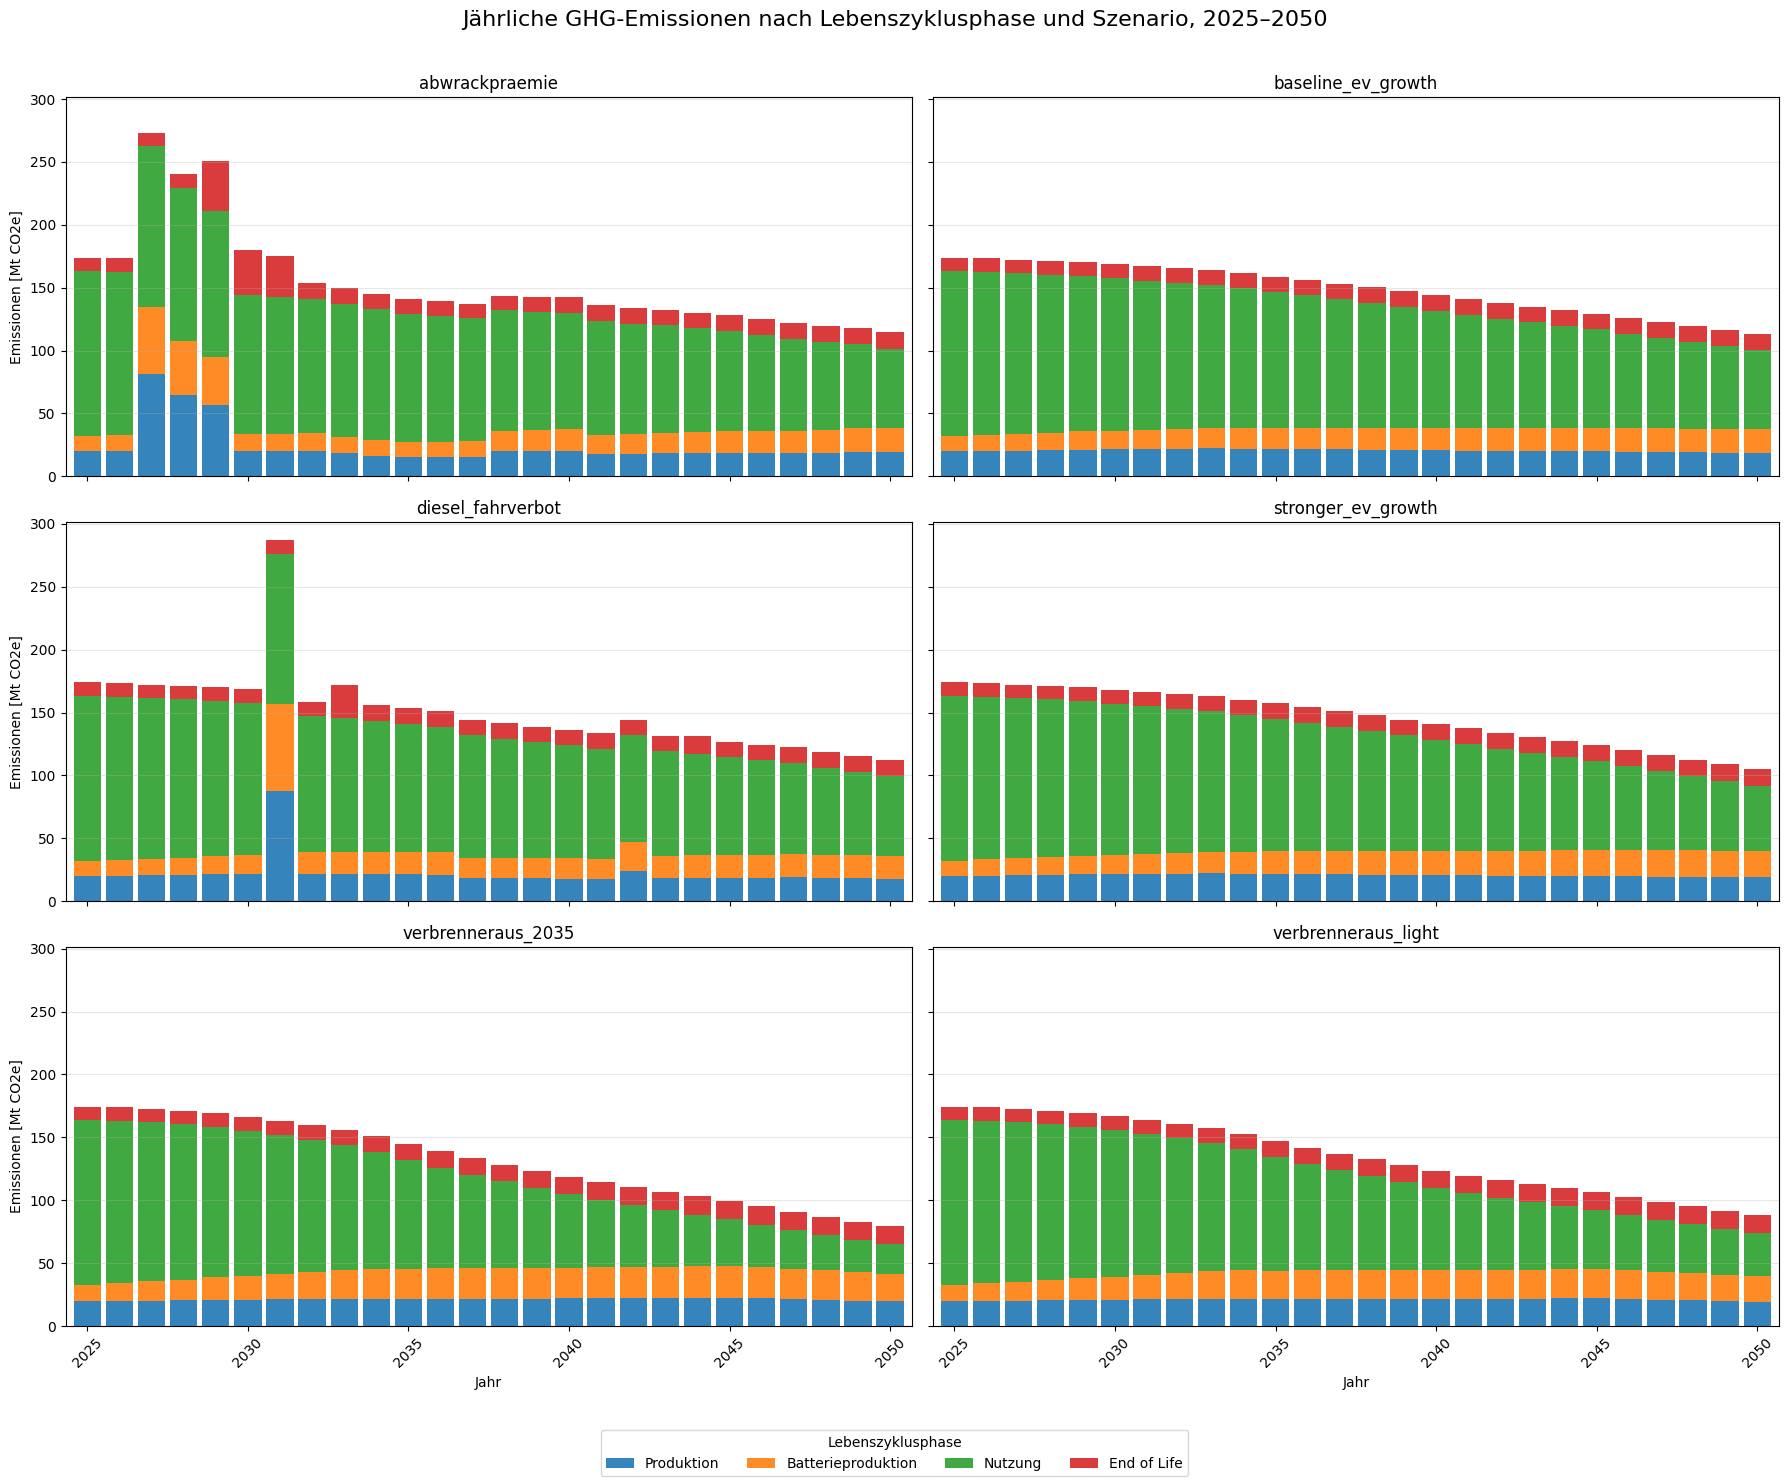

Gemeinsame Szenariengrafik gespeichert: Results\emissions_area_all_scenarios.png


In [48]:
# ============================================================
# Gestapeltes Flächendiagramm: Emissionen nach Lebenszyklusphase
# Datenquelle: bereits vorhandene Notebook-Variable emissions_by_phase
# ============================================================

from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Einstellungen
# ------------------------------------------------------------

RESULTS_DIR = Path("Results")

PHASE_ORDER = ["production", "battery_production", "use", "end_of_life"]

# Lesbare Bezeichnungen für die Legende
PHASE_LABELS = {
    "production": "Produktion",
    "battery_production": "Batterieproduktion",
    "use": "Nutzung",
    "end_of_life": "End of Life",
}


# ------------------------------------------------------------
# 2. Hilfsfunktion für sichere Dateinamen
# ------------------------------------------------------------

def make_safe_filename(text: str) -> str:
    """
    Wandelt einen Szenarionamen in einen sicheren Dateinamen um.

    Beispiele:
    'baseline' -> 'baseline'
    'Diesel Fahrverbot' -> 'diesel_fahrverbot'
    'Abwrackprämie' -> 'abwrackpraemie'
    """
    text = str(text).strip().lower()

    # Deutsche Sonderzeichen ersetzen
    text = (
        text
        .replace("ä", "ae")
        .replace("ö", "oe")
        .replace("ü", "ue")
        .replace("ß", "ss")
    )

    # Alles außer Buchstaben und Zahlen durch Unterstriche ersetzen
    text = re.sub(r"[^a-z0-9]+", "_", text)

    # Führende / abschließende Unterstriche entfernen
    text = text.strip("_")

    return text


# ------------------------------------------------------------
# 3. Prüfen, ob der Results-Ordner existiert
# ------------------------------------------------------------

if not RESULTS_DIR.exists():
    raise FileNotFoundError(
        f"Der Ordner '{RESULTS_DIR}' existiert nicht. "
        "Bitte führe zuerst die vorherigen Berechnungsschritte aus "
        "oder lege den Ordner an."
    )


# ------------------------------------------------------------
# 4. Daten direkt aus der Notebook-Variable übernehmen
# ------------------------------------------------------------

try:
    emissions = emissions_by_phase.copy()
except NameError:
    raise NameError(
        "Die Variable 'emissions_by_phase' existiert nicht im Notebook. "
        "Bitte führe zuerst die Zelle aus, in der emissions_by_phase erzeugt wird."
    )


# ------------------------------------------------------------
# 5. Benötigte Spalten prüfen
# ------------------------------------------------------------

required_columns = ["Szenario", "emission_year", "phase", "emissions_tco2e"]

missing_columns = [col for col in required_columns if col not in emissions.columns]

if missing_columns:
    raise ValueError(
        "In der Tabelle 'emissions_by_phase' fehlen folgende benötigte Spalten: "
        f"{missing_columns}\n"
        f"Vorhandene Spalten: {list(emissions.columns)}"
    )


# ------------------------------------------------------------
# 6. Numerische Spalten robust umwandeln
# ------------------------------------------------------------

emissions["emission_year"] = pd.to_numeric(
    emissions["emission_year"],
    errors="coerce",
)

emissions["emissions_tco2e"] = pd.to_numeric(
    emissions["emissions_tco2e"],
    errors="coerce",
)

# Zeilen ohne gültiges Jahr entfernen
emissions = emissions.dropna(subset=["emission_year"])

# Jahre als ganze Zahlen darstellen
emissions["emission_year"] = emissions["emission_year"].astype(int)

# Fehlende Emissionen als 0 behandeln
emissions["emissions_tco2e"] = emissions["emissions_tco2e"].fillna(0.0)


# ------------------------------------------------------------
# 7. Emissionen nach Szenario, Jahr und Phase aggregieren
# ------------------------------------------------------------

emissions_agg = (
    emissions
    .groupby(["Szenario", "emission_year", "phase"], as_index=False)
    ["emissions_tco2e"]
    .sum()
)


# ------------------------------------------------------------
# 8. Für jedes Szenario ein eigenes Diagramm erstellen
# ------------------------------------------------------------

for scenario_name, scenario_data in emissions_agg.groupby("Szenario"):

    # Pivot-Tabelle:
    # Zeilen = Jahre
    # Spalten = Lebenszyklusphasen
    # Werte = Emissionen in tCO2e
    plot_data = (
        scenario_data
        .pivot_table(
            index="emission_year",
            columns="phase",
            values="emissions_tco2e",
            aggfunc="sum",
            fill_value=0.0,
        )
        .sort_index()
    )

    # Falls eine Phase im Szenario fehlt, mit 0 ergänzen
    for phase in PHASE_ORDER:
        if phase not in plot_data.columns:
            plot_data[phase] = 0.0

    # Phasen in gewünschter Reihenfolge sortieren
    plot_data = plot_data[PHASE_ORDER]

    # --------------------------------------------------------
    # Diagramm erstellen
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(14, 7))

    plot_data.rename(columns=PHASE_LABELS).plot(
        kind="bar", stacked=True, width=0.85, ax=ax, alpha=0.9
    )

    # --------------------------------------------------------
    # Diagramm beschriften
    # --------------------------------------------------------

    ax.set_title(
        f"Jährliche Emissionen nach Lebenszyklusphase – {scenario_name}",
        fontsize=14,
    )

    ax.set_xlabel("Jahr")
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel("Emissionen [tCO2e]")

    ax.legend(
        title="Lebenszyklusphase",
        loc="upper left",
    )

    ax.grid(
        True,
        axis="y",
        alpha=0.3,
    )

    fig.tight_layout()

    # --------------------------------------------------------
    # Diagramm speichern
    # --------------------------------------------------------

    safe_scenario_name = make_safe_filename(scenario_name)
    output_file = RESULTS_DIR / f"emissions_area_{safe_scenario_name}.png"

    fig.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(f"Diagramm gespeichert: {output_file}")

# Gemeinsame 3x2-Abbildung für den direkten Vergleich aller sechs Szenarien
scenario_order = [
    "abwrackpraemie", "baseline_ev_growth", "diesel_fahrverbot",
    "stronger_ev_growth", "verbrenneraus_2035", "verbrenneraus_light",
]
available_scenarios = set(emissions_agg["Szenario"].unique())
scenario_order = [name for name in scenario_order if name in available_scenarios]
scenario_order += sorted(available_scenarios.difference(scenario_order))

fig, axes = plt.subplots(3, 2, figsize=(18, 15), sharex=True, sharey=True)
axes = axes.flatten()
for ax, scenario_name in zip(axes, scenario_order):
    scenario_data = emissions_agg.loc[emissions_agg["Szenario"].eq(scenario_name)]
    panel_data = (scenario_data.pivot_table(
        index="emission_year", columns="phase", values="emissions_tco2e",
        aggfunc="sum", fill_value=0.0,
    ).sort_index())
    for phase in PHASE_ORDER:
        if phase not in panel_data.columns:
            panel_data[phase] = 0.0
    panel_data = panel_data[PHASE_ORDER] / 1_000_000
    panel_data.rename(columns=PHASE_LABELS).plot(
        kind="bar", stacked=True, width=0.85, ax=ax, legend=False, alpha=0.9
    )
    ax.set_title(scenario_name)
    ax.set_xlabel("Jahr")
    ax.set_ylabel("Emissionen [Mt CO2e]")
    tick_positions = np.arange(0, len(panel_data), 5)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(panel_data.index[tick_positions], rotation=45)
    ax.grid(True, axis="y", alpha=0.3)
for ax in axes[len(scenario_order):]:
    ax.set_visible(False)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Lebenszyklusphase", loc="lower center", ncol=4)
fig.suptitle("Jährliche GHG-Emissionen nach Lebenszyklusphase und Szenario, 2025–2050", fontsize=16)
fig.tight_layout(rect=[0, 0.05, 1, 0.97])
all_scenarios_output = RESULTS_DIR / "emissions_area_all_scenarios.png"
fig.savefig(all_scenarios_output, dpi=300, bbox_inches="tight")
plt.show()
print(f"Gemeinsame Szenariengrafik gespeichert: {all_scenarios_output}")

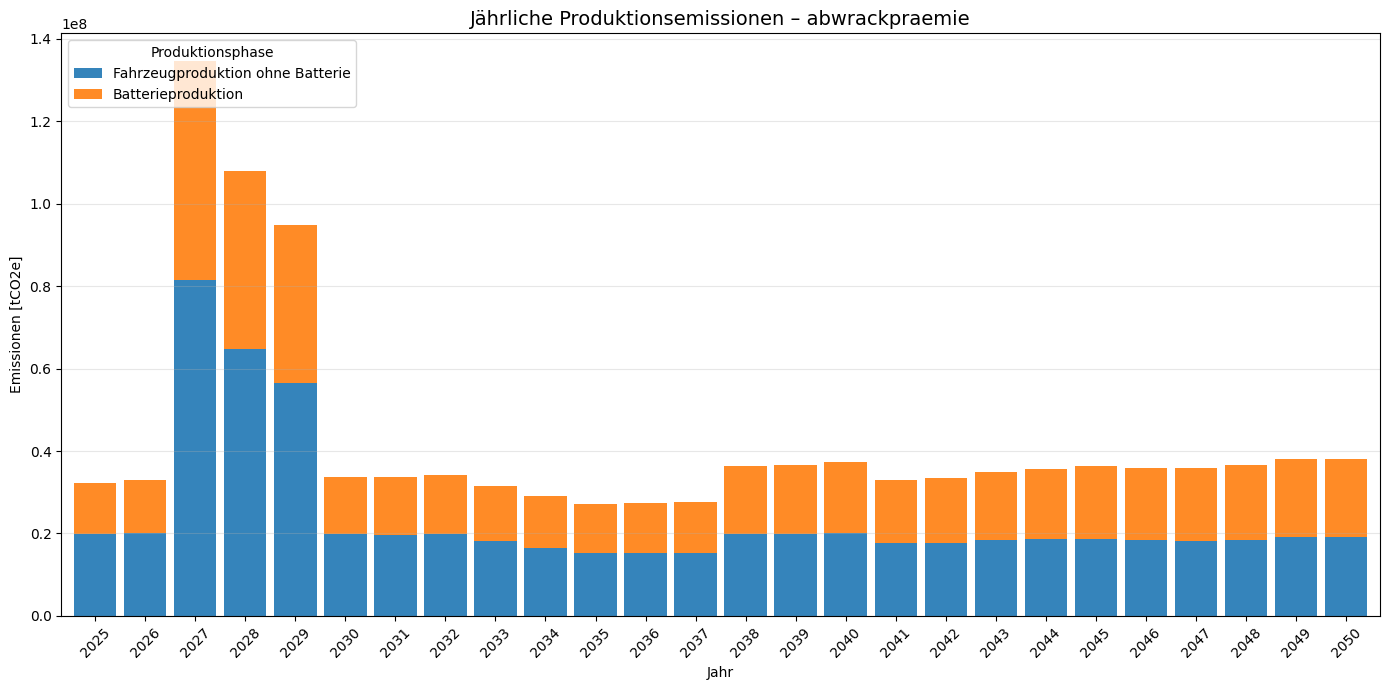

Zusätzliches Produktionsdiagramm gespeichert: Results\emissions_area_production_split_abwrackpraemie.png


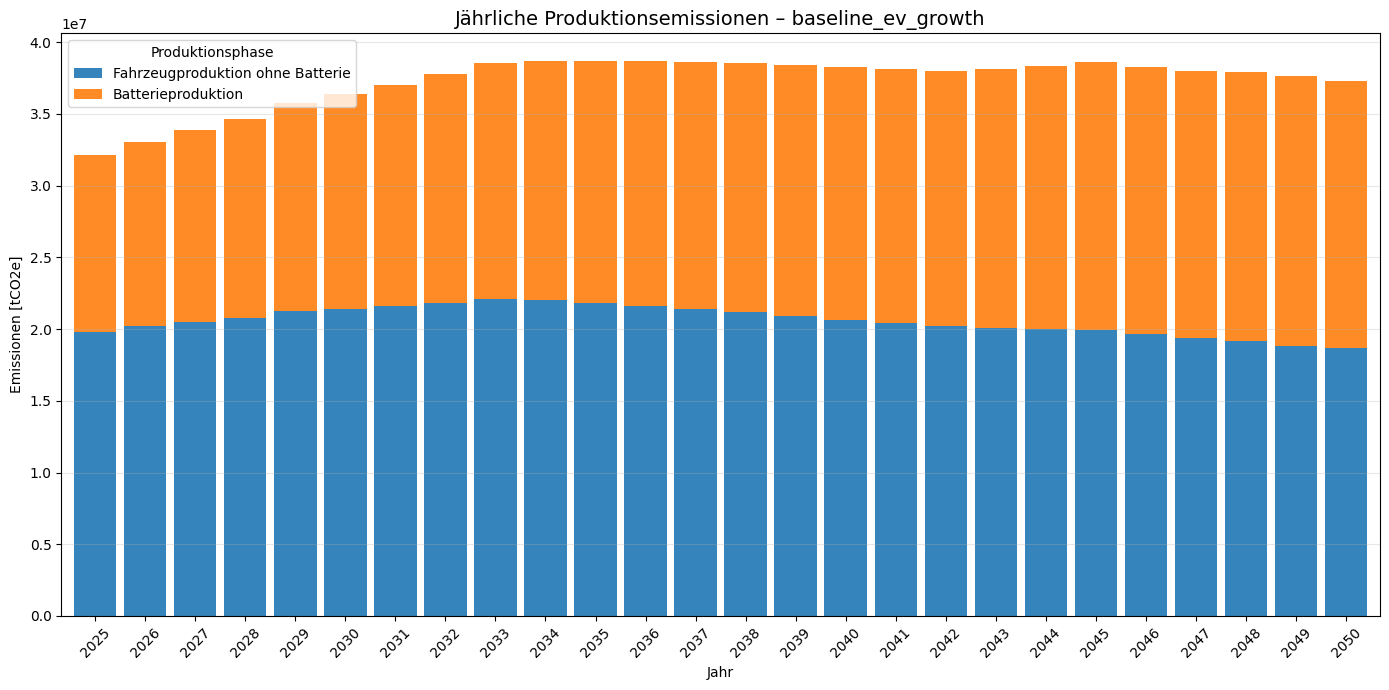

Zusätzliches Produktionsdiagramm gespeichert: Results\emissions_area_production_split_baseline_ev_growth.png


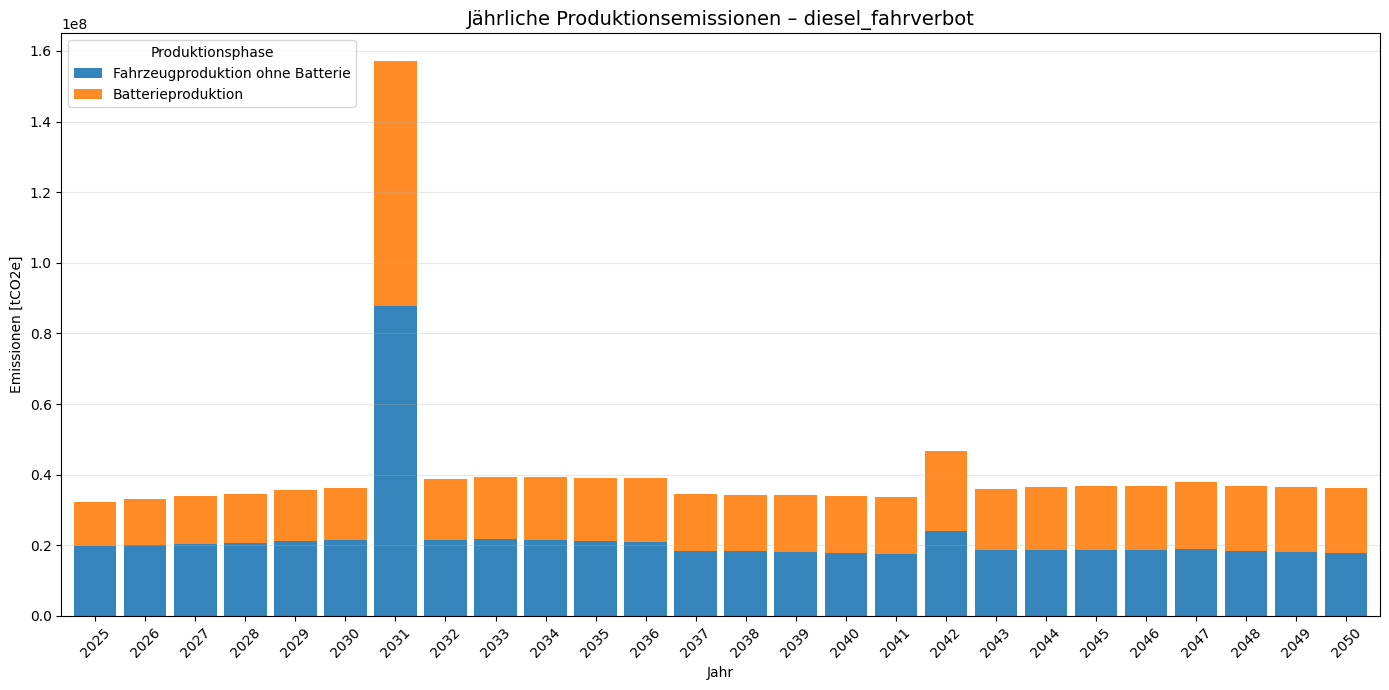

Zusätzliches Produktionsdiagramm gespeichert: Results\emissions_area_production_split_diesel_fahrverbot.png


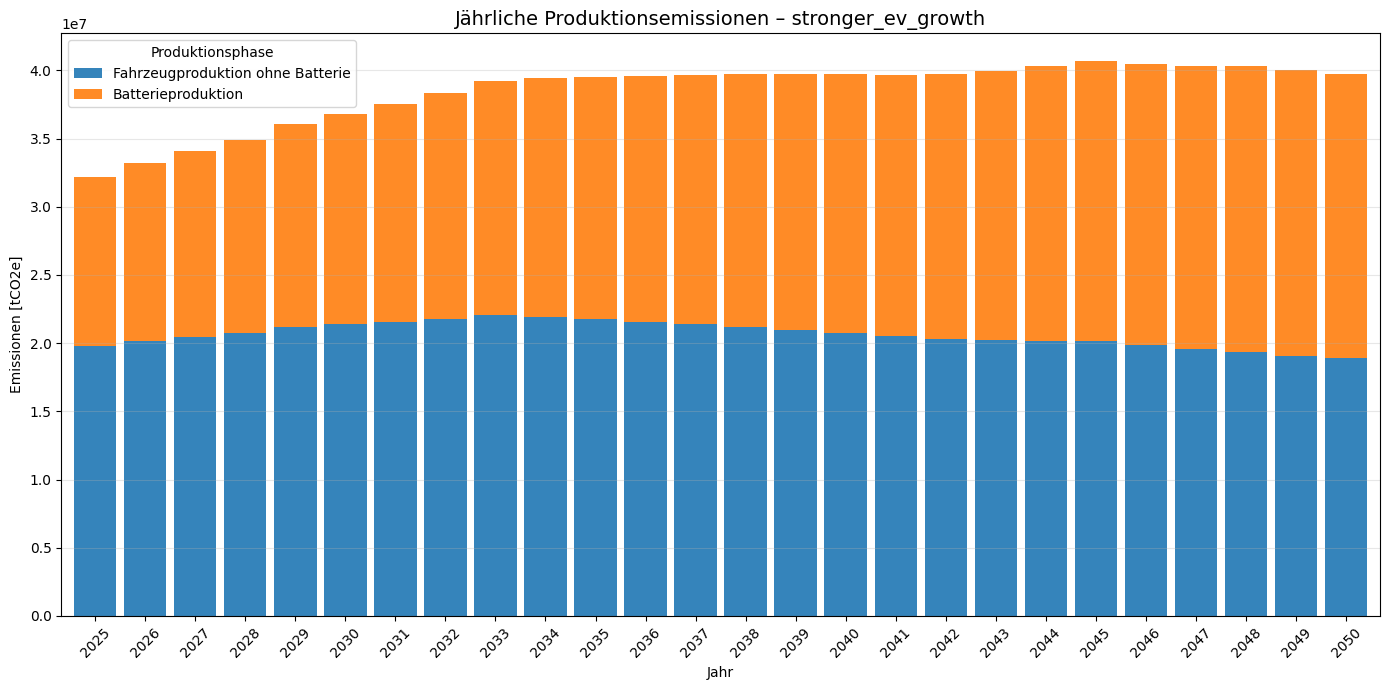

Zusätzliches Produktionsdiagramm gespeichert: Results\emissions_area_production_split_stronger_ev_growth.png


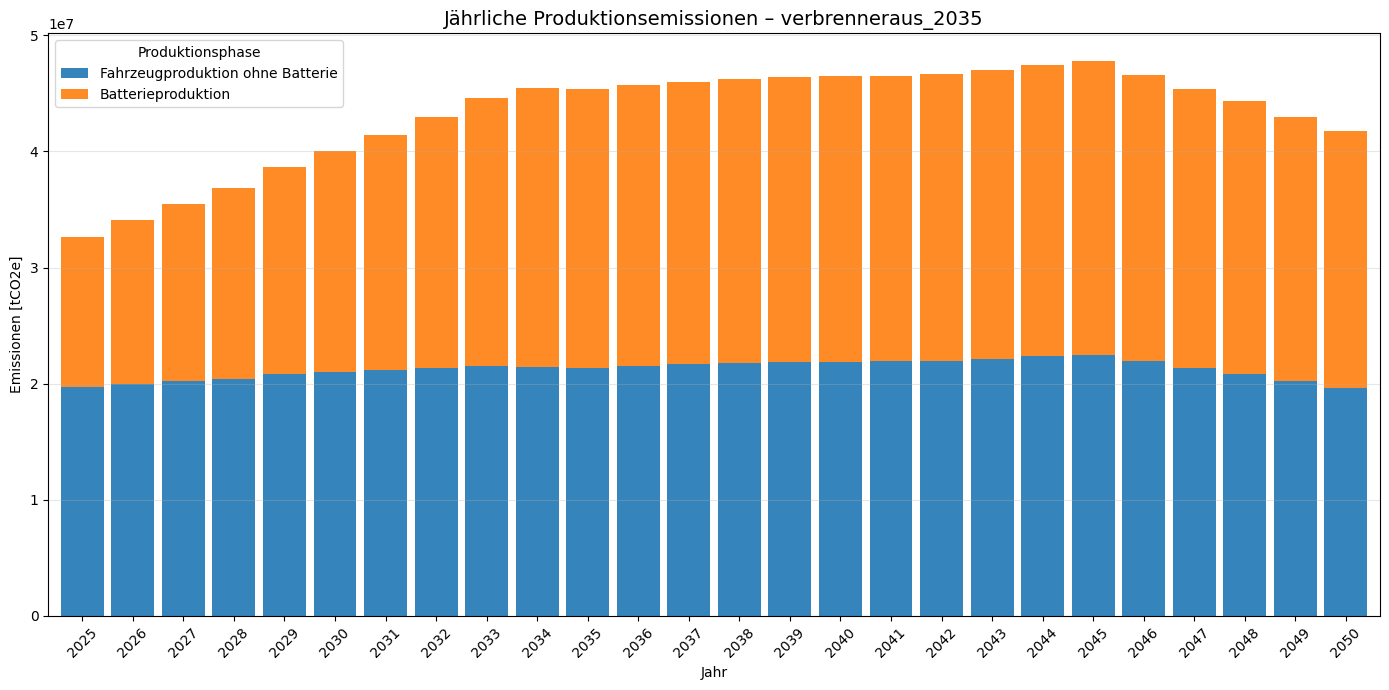

Zusätzliches Produktionsdiagramm gespeichert: Results\emissions_area_production_split_verbrenneraus_2035.png


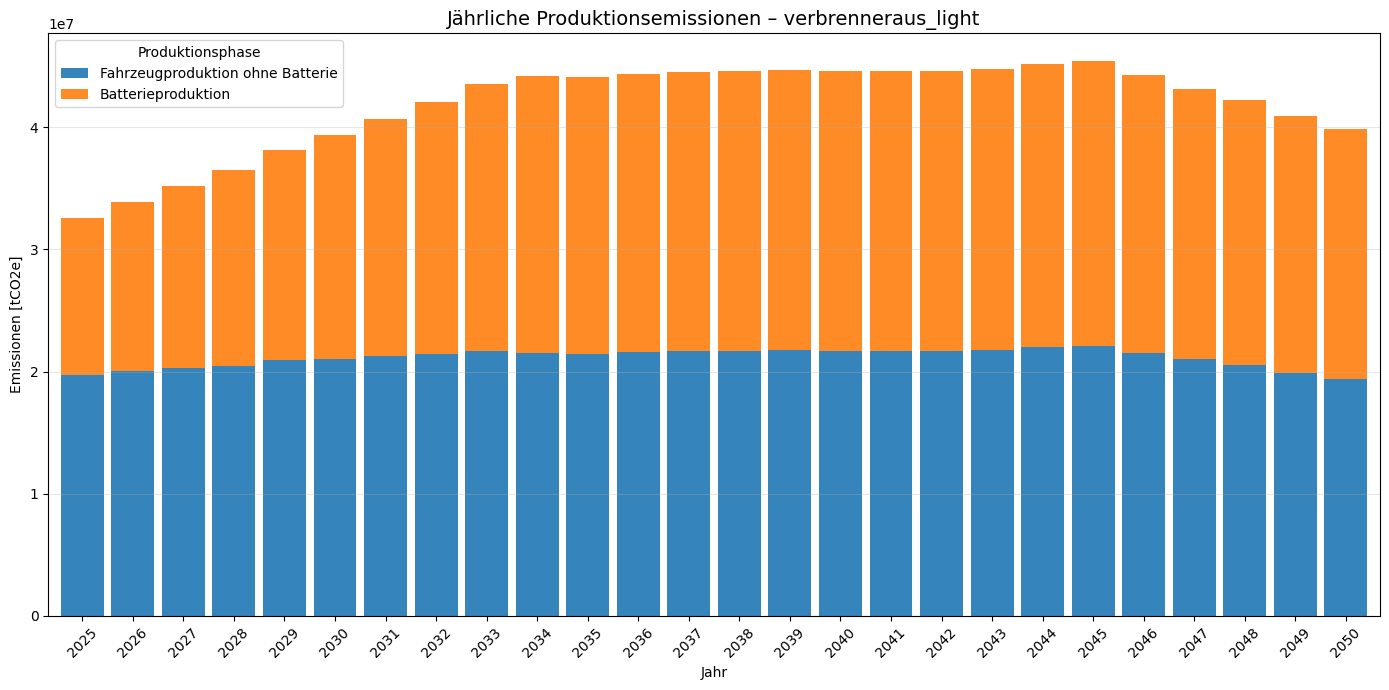

Zusätzliches Produktionsdiagramm gespeichert: Results\emissions_area_production_split_verbrenneraus_light.png


In [49]:
# ============================================================
# Zusätzliches Flächendiagramm: Produktionsphasen getrennt
# Die bestehenden Lebenszyklusdiagramme bleiben unverändert.
# ============================================================

PRODUCTION_PHASE_ORDER = ["production", "battery_production"]
PRODUCTION_PHASE_LABELS = {
    "production": "Fahrzeugproduktion ohne Batterie",
    "battery_production": "Batterieproduktion",
}

production_plot_emissions = emissions_by_phase[
    emissions_by_phase["phase"].isin(PRODUCTION_PHASE_ORDER)
].copy()
production_plot_agg = (
    production_plot_emissions
    .groupby(["Szenario", "emission_year", "phase"], as_index=False)["emissions_tco2e"]
    .sum()
)

for scenario_name, scenario_data in production_plot_agg.groupby("Szenario"):
    plot_data = (
        scenario_data
        .pivot_table(
            index="emission_year", columns="phase",
            values="emissions_tco2e", aggfunc="sum", fill_value=0.0,
        )
        .sort_index()
    )
    for phase in PRODUCTION_PHASE_ORDER:
        if phase not in plot_data.columns:
            plot_data[phase] = 0.0
    plot_data = plot_data[PRODUCTION_PHASE_ORDER]

    fig, ax = plt.subplots(figsize=(14, 7))
    plot_data.rename(columns=PRODUCTION_PHASE_LABELS).plot(
        kind="bar", stacked=True, width=0.85, ax=ax, alpha=0.9
    )
    ax.set_title(f"Jährliche Produktionsemissionen – {scenario_name}", fontsize=14)
    ax.set_xlabel("Jahr")
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel("Emissionen [tCO2e]")
    ax.legend(title="Produktionsphase", loc="upper left")
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()

    safe_scenario_name = make_safe_filename(scenario_name)
    output_file = RESULTS_DIR / f"emissions_area_production_split_{safe_scenario_name}.png"
    fig.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Zusätzliches Produktionsdiagramm gespeichert: {output_file}")


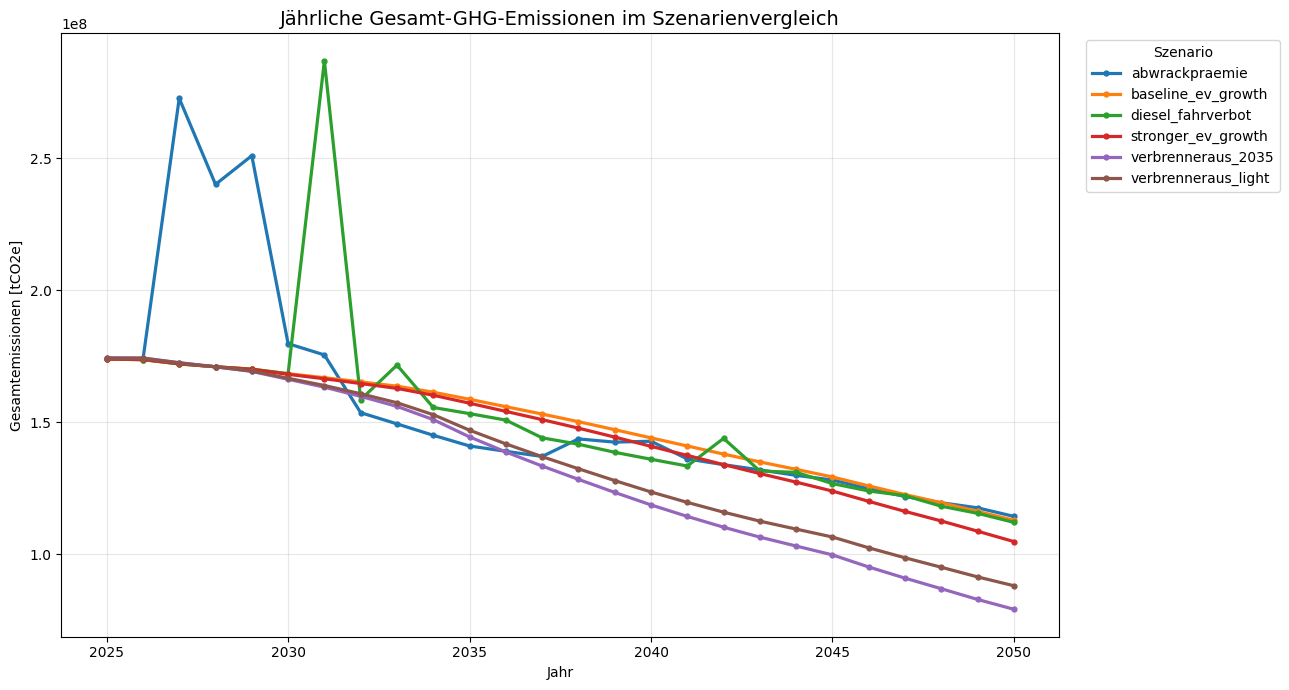

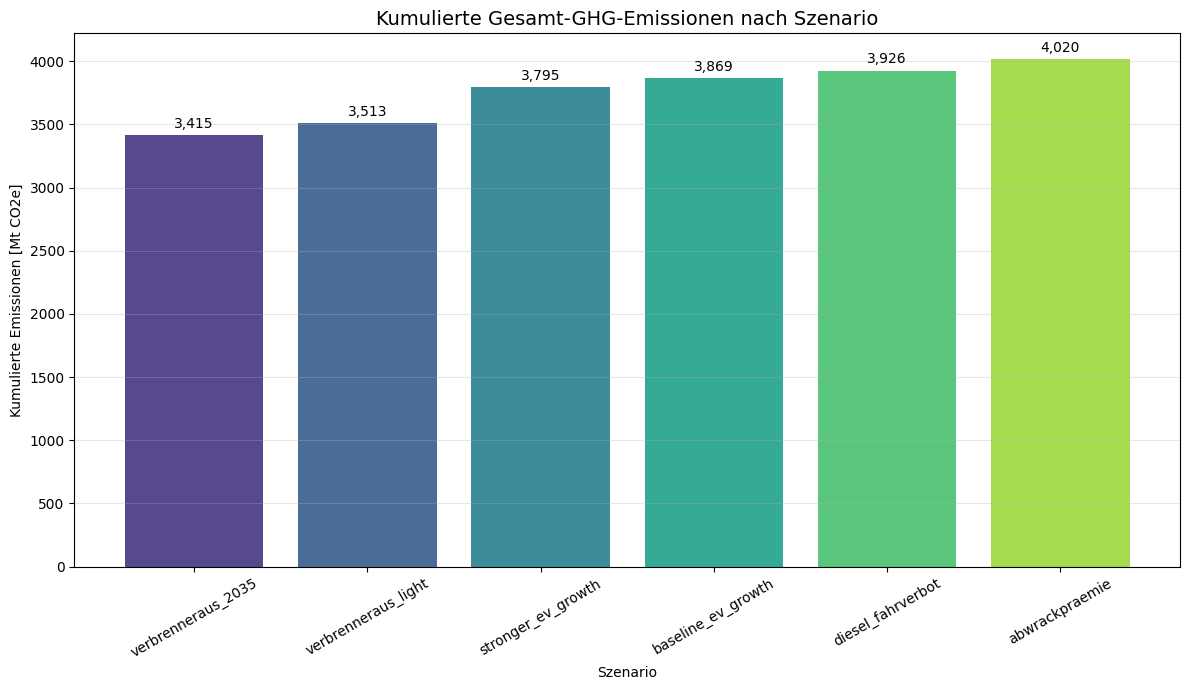

,Szenario,total_emissions_tco2e,total_emissions_MtCO2e
4,verbrenneraus_2035,3.414703e+09,3414.703
5,verbrenneraus_light,3.513264e+09,3513.264
3,stronger_ev_growth,3.795051e+09,3795.051
1,baseline_ev_growth,3.868956e+09,3868.956
2,diesel_fahrverbot,3.925886e+09,3925.886
0,abwrackpraemie,4.019786e+09,4019.786


Vergleichsgrafik gespeichert: Results\emissions_total_scenarios_comparison.png
Kumulierte Vergleichsgrafik gespeichert: Results\emissions_cumulative_scenarios_comparison.png
Aggregierte Emissionstabellen wurden im Results-Ordner gespeichert.


In [50]:
# ============================================================
# Vergleich der gesamten GHG-Emissionen aller Szenarien
# Einschließlich Fahrzeug- und Batterieproduktion, Nutzung und EoL
# ============================================================

emissions_summary_by_year_phase = (
    emissions_by_phase
    .groupby(["Szenario", "emission_year", "phase"], as_index=False)["emissions_tco2e"]
    .sum()
)
emissions_summary_by_year_total = (
    emissions_by_phase
    .groupby(["Szenario", "emission_year"], as_index=False)["emissions_tco2e"]
    .sum()
    .rename(columns={"emissions_tco2e": "total_emissions_tco2e"})
)
emissions_summary_total_by_scenario = (
    emissions_summary_by_year_total
    .groupby("Szenario", as_index=False)["total_emissions_tco2e"]
    .sum()
    .sort_values("total_emissions_tco2e")
)

emissions_by_phase.to_csv(OUT_EMISSIONS_BY_PHASE, sep=CSV_SEP, encoding=CSV_ENCODING, index=False)
emissions_summary_by_year_phase.to_csv(OUT_SUMMARY_YEAR_PHASE, sep=CSV_SEP, encoding=CSV_ENCODING, index=False)
emissions_summary_by_year_total.to_csv(OUT_SUMMARY_YEAR_TOTAL, sep=CSV_SEP, encoding=CSV_ENCODING, index=False)
emissions_summary_total_by_scenario.to_csv(OUT_SUMMARY_TOTAL_SCENARIO, sep=CSV_SEP, encoding=CSV_ENCODING, index=False)

comparison = emissions_summary_by_year_total.pivot(
    index="emission_year", columns="Szenario", values="total_emissions_tco2e"
).sort_index()
fig, ax = plt.subplots(figsize=(13, 7))
comparison.plot(kind="line", ax=ax, linewidth=2.3, marker="o", markersize=3.5)
ax.set_title("Jährliche Gesamt-GHG-Emissionen im Szenarienvergleich", fontsize=14)
ax.set_xlabel("Jahr")
ax.set_ylabel("Gesamtemissionen [tCO2e]")
ax.tick_params(axis="x", rotation=0)
ax.grid(True, alpha=0.3)
ax.legend(title="Szenario", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
comparison_output = RESULTS_DIR / "emissions_total_scenarios_comparison.png"
fig.savefig(comparison_output, dpi=300, bbox_inches="tight")
plt.show()

# Kumulierte Gesamtemissionen über den gesamten Betrachtungszeitraum
cumulative_plot = emissions_summary_total_by_scenario.copy()
cumulative_plot["total_emissions_MtCO2e"] = cumulative_plot["total_emissions_tco2e"] / 1_000_000
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.bar(
    cumulative_plot["Szenario"], cumulative_plot["total_emissions_MtCO2e"],
    color=plt.cm.viridis(np.linspace(0.15, 0.85, len(cumulative_plot))), alpha=0.9,
)
ax.bar_label(bars, labels=[f"{value:,.0f}" for value in cumulative_plot["total_emissions_MtCO2e"]], padding=3)
ax.set_title("Kumulierte Gesamt-GHG-Emissionen nach Szenario", fontsize=14)
ax.set_xlabel("Szenario")
ax.set_ylabel("Kumulierte Emissionen [Mt CO2e]")
ax.tick_params(axis="x", rotation=30)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
cumulative_output = RESULTS_DIR / "emissions_cumulative_scenarios_comparison.png"
fig.savefig(cumulative_output, dpi=300, bbox_inches="tight")
plt.show()

display(emissions_summary_total_by_scenario.assign(
    total_emissions_MtCO2e=lambda x: x["total_emissions_tco2e"] / 1_000_000
).round(3))
print(f"Vergleichsgrafik gespeichert: {comparison_output}")
print(f"Kumulierte Vergleichsgrafik gespeichert: {cumulative_output}")
print("Aggregierte Emissionstabellen wurden im Results-Ordner gespeichert.")


# Publication-ready scenario table

The production shares below are calculated as cumulative production emissions divided by cumulative total emissions. This emissions-weighted definition is preferable to an unweighted mean of annual shares.

In [51]:
# ============================================================
# Publication-ready summary table by scenario
# ============================================================

SCENARIO_LABELS = {
    "baseline_ev_growth": "Baseline EV growth",
    "stronger_ev_growth": "Stronger EV growth",
    "abwrackpraemie": "Scrappage premium",
    "diesel_fahrverbot": "Diesel ban",
    "verbrenneraus_2035": "ICE phase-out 2035",
    "verbrenneraus_light": "Lighter ICE phase-out",
}
SCENARIO_ORDER = [
    "baseline_ev_growth", "stronger_ev_growth",
    "abwrackpraemie", "diesel_fahrverbot",
    "verbrenneraus_2035", "verbrenneraus_light",
]
BASELINE_SCENARIO = "baseline_ev_growth"

# Cumulative emissions by life-cycle phase
phase_cumulative = (
    emissions_summary_by_year_phase
    .groupby(["Szenario", "phase"], as_index=False)["emissions_tco2e"].sum()
    .pivot(index="Szenario", columns="phase", values="emissions_tco2e")
    .fillna(0.0)
)
for phase in ["production", "battery_production", "use", "end_of_life"]:
    if phase not in phase_cumulative.columns:
        phase_cumulative[phase] = 0.0
phase_cumulative["total"] = phase_cumulative[
    ["production", "battery_production", "use", "end_of_life"]
].sum(axis=1)

# Annual emissions in the final analysis year
annual_2050 = (
    emissions_summary_by_year_total.loc[
        emissions_summary_by_year_total["emission_year"].eq(ANALYSIS_END_YEAR)
    ].set_index("Szenario")["total_emissions_tco2e"]
)

# Fleet indicators
new_registrations = (
    new_vehicles.loc[new_vehicles["Jahr"].between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)]
    .groupby("Szenario")["neue_fahrzeuge"].sum()
)
cumulative_exits = (
    exits.loc[exits["Jahr"].between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)]
    .groupby("Szenario")["exits"].sum()
)
stock_2050 = final_stock.loc[final_stock["Jahr"].eq(ANALYSIS_END_YEAR)].copy()
total_stock_2050 = stock_2050.groupby("Szenario")["finaler_bestand"].sum()
bev_stock_2050 = (
    stock_2050.loc[stock_2050["Antriebsart"].eq("Elektro (BEV)")]
    .groupby("Szenario")["finaler_bestand"].sum()
)

paper_table = pd.DataFrame(index=phase_cumulative.index)
paper_table["Cumulative GHG\n[Gt CO2e]"] = phase_cumulative["total"] / 1e9
baseline_total = phase_cumulative.loc[BASELINE_SCENARIO, "total"]
paper_table["vs. baseline\n[%]"] = (phase_cumulative["total"] / baseline_total - 1) * 100
paper_table["Production incl. battery\n[% of GHG]"] = (
    (phase_cumulative["production"] + phase_cumulative["battery_production"])
    / phase_cumulative["total"] * 100
)
paper_table["Battery production\n[% of GHG]"] = (
    phase_cumulative["battery_production"] / phase_cumulative["total"] * 100
)
paper_table["Annual GHG 2050\n[Mt CO2e/yr]"] = annual_2050 / 1e6
paper_table["New registrations\n[million]"] = new_registrations / 1e6
paper_table["Additional exits\nvs. baseline [million]"] = (
    cumulative_exits - cumulative_exits.loc[BASELINE_SCENARIO]
) / 1e6
paper_table["BEV stock share 2050\n[%]"] = (
    bev_stock_2050.reindex(total_stock_2050.index, fill_value=0)
    / total_stock_2050 * 100
)

available_order = [s for s in SCENARIO_ORDER if s in paper_table.index]
available_order += [s for s in paper_table.index if s not in available_order]
paper_table = paper_table.reindex(available_order)
paper_table.index = paper_table.index.map(lambda s: SCENARIO_LABELS.get(s, s))
paper_table.index.name = "Scenario"
paper_table_rounded = paper_table.round(2)

display(
    paper_table_rounded.style
    .format(precision=2)
    .set_caption("Table X. Cumulative GHG emissions and fleet indicators by scenario, 2025–2050.")
)

# Files for straightforward transfer to Word/Excel or LaTeX
paper_table_csv = RESULTS_DIR / "paper_scenario_summary_table.csv"
paper_table_tex = RESULTS_DIR / "paper_scenario_summary_table.tex"
paper_table_rounded.to_csv(paper_table_csv, sep=";", encoding=CSV_ENCODING)
paper_table_rounded.to_latex(
    paper_table_tex,
    index=True,
    float_format=lambda value: f"{value:.2f}",
    caption="Cumulative GHG emissions and fleet indicators by scenario, 2025--2050.",
    label="tab:scenario_summary",
    position="htbp",
)

print(f"CSV table saved to: {paper_table_csv}")
print(f"LaTeX table saved to: {paper_table_tex}")
print("Note: Production shares are cumulative emission-weighted shares.")
print("New registrations and exits cover model years 2025–2050; production emissions are assigned one year before registration.")

,Cumulative GHG [Gt CO2e],vs. baseline [%],Production incl. battery [% of GHG],Battery production [% of GHG],Annual GHG 2050 [Mt CO2e/yr],New registrations [million],Additional exits vs. baseline [million],BEV stock share 2050 [%]
Scenario,,,,,,,,
Baseline EV growth,3.87,0.00,25.06,11.22,112.92,75.23,0.00,50.24
Stronger EV growth,3.80,-1.91,26.37,12.23,104.81,76.04,0.02,59.69
Scrappage premium,4.02,3.90,27.73,12.14,114.36,87.99,50.89,50.00
Diesel ban,3.93,1.47,27.25,12.45,112.09,82.37,7.47,50.46
ICE phase-out 2035,3.41,-11.74,32.94,16.76,79.16,80.55,0.98,84.67
Lighter ICE phase-out,3.51,-9.19,30.96,15.31,88.08,79.42,0.85,74.92


CSV table saved to: Results\paper_scenario_summary_table.csv
LaTeX table saved to: Results\paper_scenario_summary_table.tex
Note: Production shares are cumulative emission-weighted shares.
New registrations and exits cover model years 2025–2050; production emissions are assigned one year before registration.


## Verification of production-emission shares in 2050

The first table reports annual emissions and shares for the ICE phase-out scenario in 2050. The second table reports cumulative values for 2025–2050. This distinction is important because the production shares in the scenario summary table are cumulative, whereas the stacked chart shows annual emissions.

In [52]:
# Inspect annual phase emissions in 2050
scenario_to_check = "verbrenneraus_2035"
year_to_check = 2050

phase_2050 = (
    emissions_summary_by_year_phase.loc[
        emissions_summary_by_year_phase["Szenario"].eq(scenario_to_check)
        & emissions_summary_by_year_phase["emission_year"].eq(year_to_check)
    ]
    .groupby("phase", as_index=False)["emissions_tco2e"].sum()
)
phase_2050["emissions_MtCO2e"] = phase_2050["emissions_tco2e"] / 1e6
phase_2050["share_percent"] = (
    100 * phase_2050["emissions_tco2e"] / phase_2050["emissions_tco2e"].sum()
)
display(phase_2050[["phase", "emissions_MtCO2e", "share_percent"]].round(2))

production_2050 = phase_2050.loc[
    phase_2050["phase"].isin(["production", "battery_production"]),
    "emissions_tco2e",
].sum()
print(f"Production incl. battery in 2050: {production_2050 / 1e6:.2f} Mt CO2e")
print(f"Production incl. battery share in 2050: {100 * production_2050 / phase_2050['emissions_tco2e'].sum():.2f}%")

# Compare with cumulative phase shares over the full analysis period
phase_cumulative_check = (
    emissions_summary_by_year_phase.loc[
        emissions_summary_by_year_phase["Szenario"].eq(scenario_to_check)
        & emissions_summary_by_year_phase["emission_year"].between(
            ANALYSIS_START_YEAR, ANALYSIS_END_YEAR
        )
    ]
    .groupby("phase", as_index=False)["emissions_tco2e"].sum()
)
phase_cumulative_check["emissions_GtCO2e"] = (
    phase_cumulative_check["emissions_tco2e"] / 1e9
)
phase_cumulative_check["share_percent"] = (
    100 * phase_cumulative_check["emissions_tco2e"]
    / phase_cumulative_check["emissions_tco2e"].sum()
)
display(phase_cumulative_check[["phase", "emissions_GtCO2e", "share_percent"]].round(2))

,phase,emissions_MtCO2e,share_percent
0,battery_production,22.07,27.89
1,end_of_life,14.23,17.98
2,production,19.65,24.83
3,use,23.20,29.31


Production incl. battery in 2050: 41.73 Mt CO2e
Production incl. battery share in 2050: 52.71%


,phase,emissions_GtCO2e,share_percent
0,battery_production,0.57,16.76
1,end_of_life,0.34,9.87
2,production,0.55,16.19
3,use,1.95,57.19


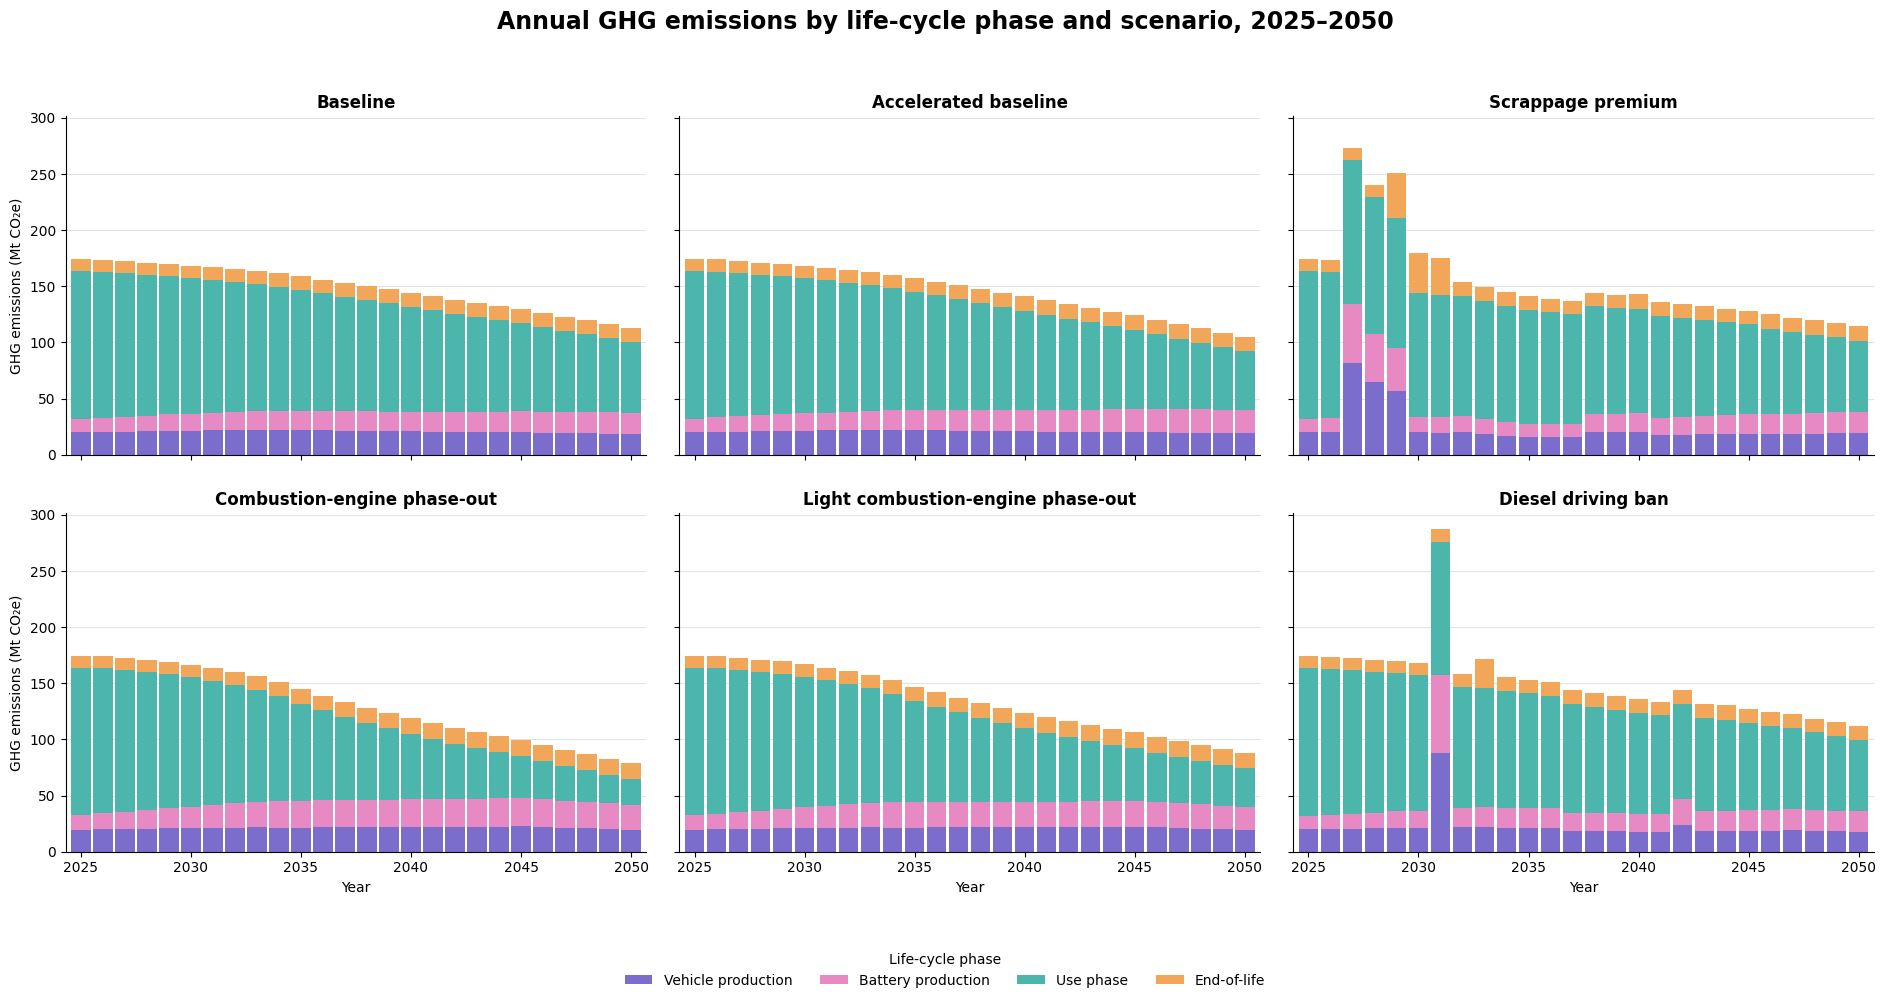

Figure saved to:
Results\annual_ghg_emissions_by_phase_and_scenario_2025_2050.png


In [53]:
# Annual GHG emissions by life-cycle phase and scenario (English, publication layout)
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plot_emissions = emissions_by_phase.copy()
required_columns = ["Szenario", "emission_year", "phase", "emissions_tco2e"]
missing_columns = [column for column in required_columns if column not in plot_emissions.columns]
if missing_columns:
    raise ValueError(f"Missing columns in emissions_by_phase: {missing_columns}")

plot_emissions["emission_year"] = pd.to_numeric(plot_emissions["emission_year"], errors="coerce")
plot_emissions["emissions_tco2e"] = pd.to_numeric(plot_emissions["emissions_tco2e"], errors="coerce")
plot_emissions = plot_emissions.dropna(subset=["emission_year"])
plot_emissions["emission_year"] = plot_emissions["emission_year"].astype(int)
plot_emissions["emissions_tco2e"] = plot_emissions["emissions_tco2e"].fillna(0.0)
plot_emissions = plot_emissions[plot_emissions["emission_year"].between(2025, 2050)]

scenario_order = [
    "baseline_ev_growth",
    "stronger_ev_growth",
    "abwrackpraemie",
    "verbrenneraus_2035",
    "verbrenneraus_light",
    "diesel_fahrverbot",
]
scenario_labels = {
    "baseline_ev_growth": "Baseline",
    "stronger_ev_growth": "Accelerated baseline",
    "abwrackpraemie": "Scrappage premium",
    "verbrenneraus_2035": "Combustion-engine phase-out",
    "verbrenneraus_light": "Light combustion-engine phase-out",
    "diesel_fahrverbot": "Diesel driving ban",
}
phase_order = ["production", "battery_production", "use", "end_of_life"]
phase_labels = {
    "production": "Vehicle production",
    "battery_production": "Battery production",
    "use": "Use phase",
    "end_of_life": "End-of-life",
}
phase_colors = {
    "production": "#7B6DCC",
    "battery_production": "#E78AC3",
    "use": "#4DB6AC",
    "end_of_life": "#F2A65A",
}

emissions_plot_agg = (
    plot_emissions.groupby(["Szenario", "emission_year", "phase"], as_index=False)["emissions_tco2e"]
    .sum()
)
available_scenarios = set(emissions_plot_agg["Szenario"].unique())
missing_scenarios = [scenario for scenario in scenario_order if scenario not in available_scenarios]
if missing_scenarios:
    raise ValueError(f"Scenarios missing from emissions_by_phase: {missing_scenarios}")

fig, axes = plt.subplots(2, 3, figsize=(19, 10), sharex=True, sharey=True, squeeze=False)
years = range(2025, 2051)
colors = [phase_colors[phase] for phase in phase_order]

for ax, scenario in zip(axes.flat, scenario_order):
    panel_data = (
        emissions_plot_agg.loc[emissions_plot_agg["Szenario"] == scenario]
        .pivot_table(index="emission_year", columns="phase", values="emissions_tco2e", aggfunc="sum", fill_value=0.0)
        .reindex(index=years, columns=phase_order, fill_value=0.0)
        / 1_000_000
    )
    panel_data.rename(columns=phase_labels).plot(
        kind="bar", stacked=True, ax=ax, width=0.88, color=colors, edgecolor="none", legend=False
    )
    ax.set_title(scenario_labels[scenario], fontsize=12, fontweight="semibold")
    ax.set_xlabel("Year")
    ax.set_ylabel("GHG emissions (Mt CO₂e)")
    tick_positions = list(range(0, len(panel_data.index), 5))
    if len(panel_data.index) - 1 not in tick_positions:
        tick_positions.append(len(panel_data.index) - 1)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([panel_data.index[i] for i in tick_positions], rotation=0)
    ax.grid(axis="y", color="#D1D5DB", linewidth=0.7, alpha=0.7)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

handles, _ = axes.flat[0].get_legend_handles_labels()
legend_labels = [phase_labels[phase] for phase in phase_order]
fig.legend(handles, legend_labels, title="Life-cycle phase", loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Annual GHG emissions by life-cycle phase and scenario, 2025–2050", fontsize=17, fontweight="bold")
fig.tight_layout(rect=[0, 0.08, 1, 0.95], h_pad=2.0, w_pad=1.5)

output_directory = RESULTS_DIR if "RESULTS_DIR" in globals() else Path("Results")
output_directory.mkdir(parents=True, exist_ok=True)
output_path = output_directory / "annual_ghg_emissions_by_phase_and_scenario_2025_2050.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Figure saved to:\n{output_path}")

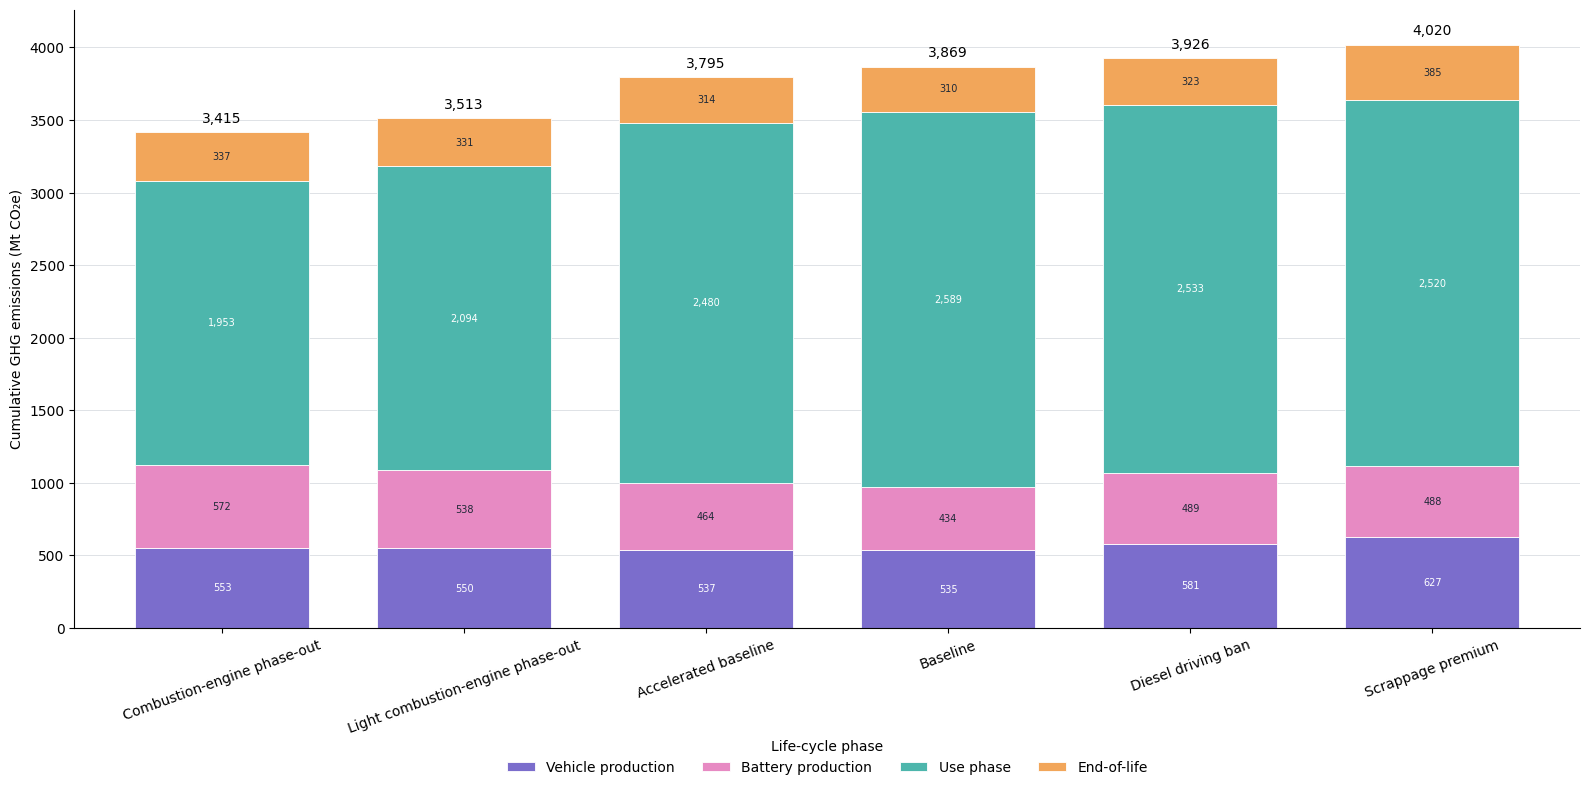

Figure saved to:
Results\cumulative_ghg_emissions_by_scenario_and_phase_2025_2050.png


In [54]:
# Cumulative GHG emissions by scenario and life-cycle phase (no title)
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

cumulative_source = emissions_by_phase.copy()
cumulative_source["emission_year"] = pd.to_numeric(cumulative_source["emission_year"], errors="coerce")
cumulative_source["emissions_tco2e"] = pd.to_numeric(cumulative_source["emissions_tco2e"], errors="coerce").fillna(0.0)
cumulative_source = cumulative_source[cumulative_source["emission_year"].between(2025, 2050)]

cumulative_scenario_order = [
    "baseline_ev_growth",
    "stronger_ev_growth",
    "abwrackpraemie",
    "verbrenneraus_2035",
    "verbrenneraus_light",
    "diesel_fahrverbot",
]
cumulative_scenario_labels = {
    "baseline_ev_growth": "Baseline",
    "stronger_ev_growth": "Accelerated baseline",
    "abwrackpraemie": "Scrappage premium",
    "verbrenneraus_2035": "Combustion-engine phase-out",
    "verbrenneraus_light": "Light combustion-engine phase-out",
    "diesel_fahrverbot": "Diesel driving ban",
}
cumulative_phase_order = ["production", "battery_production", "use", "end_of_life"]
cumulative_phase_labels = {
    "production": "Vehicle production",
    "battery_production": "Battery production",
    "use": "Use phase",
    "end_of_life": "End-of-life",
}
cumulative_phase_colors = {
    "production": "#7B6DCC",
    "battery_production": "#E78AC3",
    "use": "#4DB6AC",
    "end_of_life": "#F2A65A",
}

cumulative_plot = (
    cumulative_source.groupby(["Szenario", "phase"])["emissions_tco2e"]
    .sum()
    .unstack(fill_value=0.0)
    .reindex(index=cumulative_scenario_order, columns=cumulative_phase_order, fill_value=0.0)
    / 1_000_000
)
cumulative_plot.index = [cumulative_scenario_labels[scenario] for scenario in cumulative_plot.index]
cumulative_plot = cumulative_plot.rename(columns=cumulative_phase_labels)
cumulative_plot = cumulative_plot.loc[cumulative_plot.sum(axis=1).sort_values().index]
totals = cumulative_plot.sum(axis=1)

fig, ax = plt.subplots(figsize=(16, 8))
cumulative_plot.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.72,
    color=[cumulative_phase_colors[phase] for phase in cumulative_phase_order],
    edgecolor="white",
    linewidth=0.6,
)

# Add the disaggregated phase values inside each stacked bar.
for position, (_, row) in enumerate(cumulative_plot.iterrows()):
    lower_edge = 0.0
    for phase_label, phase_value in row.items():
        if phase_value > 0:
            ax.text(
                position,
                lower_edge + phase_value / 2,
                f"{phase_value:,.0f}",
                ha="center",
                va="center",
                fontsize=7,
                color="white" if phase_label in {"Vehicle production", "Use phase"} else "#1F2937",
            )
        lower_edge += phase_value

label_offset = max(totals.max() * 0.012, 1.0)
for position, total in enumerate(totals):
    ax.text(position, total + label_offset, f"{total:,.0f}", ha="center", va="bottom", fontsize=10)

ax.set_xlabel("")
ax.set_ylabel("Cumulative GHG emissions (Mt CO₂e)")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", color="#D1D5DB", linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Life-cycle phase", ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.16), frameon=False)
ax.set_ylim(0, totals.max() + 5 * label_offset)
fig.tight_layout()

output_directory = RESULTS_DIR if "RESULTS_DIR" in globals() else Path("Results")
output_directory.mkdir(parents=True, exist_ok=True)
output_path = output_directory / "cumulative_ghg_emissions_by_scenario_and_phase_2025_2050.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Figure saved to:\n{output_path}")

## German transport emission targets and modelled scenario emissions, 2025–2040

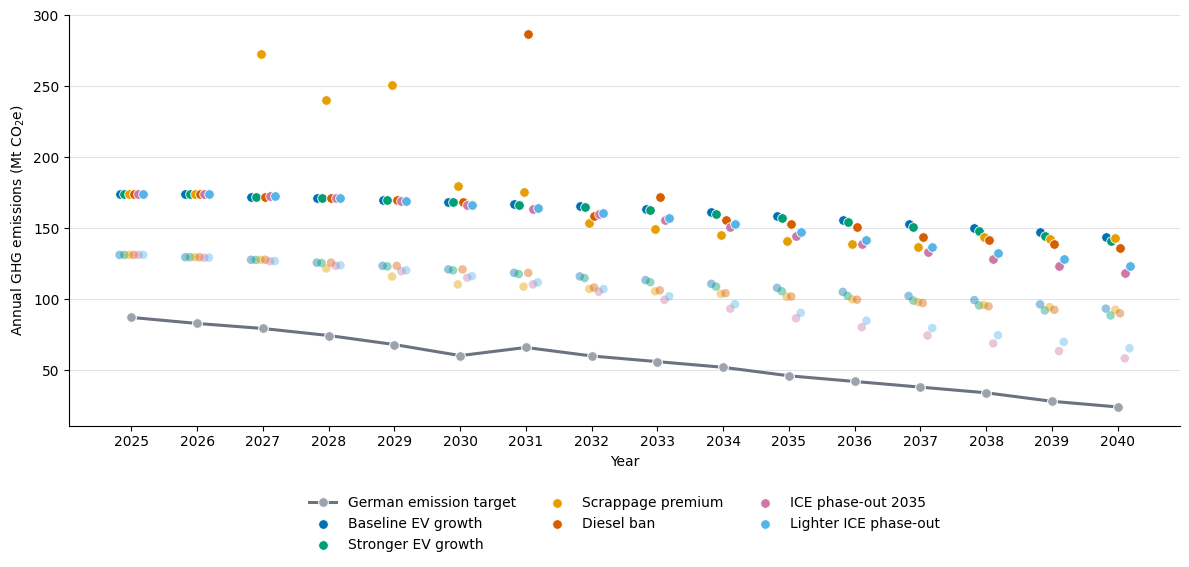

Figure saved to:
Results\german_emission_targets_and_modelled_scenarios_2025_2040.png


In [55]:
# German transport emission targets and modelled annual emissions by scenario
target_emissions = pd.Series(
    [
        87.084, 82.836, 79.296, 74.340, 67.968, 60.180,
        65.91639411, 59.92254545, 55.92133266, 51.93606094, 45.94221229,
        41.94099949, 37.95572778, 33.95451498, 27.96066633, 23.97539462,
    ],
    index=range(2025, 2041),
    name="German emission target",
)

target_scenario_order = [
    "baseline_ev_growth",
    "stronger_ev_growth",
    "abwrackpraemie",
    "diesel_fahrverbot",
    "verbrenneraus_2035",
    "verbrenneraus_light",
]
target_scenario_labels = {
    "baseline_ev_growth": "Baseline EV growth",
    "stronger_ev_growth": "Stronger EV growth",
    "abwrackpraemie": "Scrappage premium",
    "diesel_fahrverbot": "Diesel ban",
    "verbrenneraus_2035": "ICE phase-out 2035",
    "verbrenneraus_light": "Lighter ICE phase-out",
}
target_scenario_colors = {
    "baseline_ev_growth": "#0072B2",
    "stronger_ev_growth": "#009E73",
    "abwrackpraemie": "#E69F00",
    "diesel_fahrverbot": "#D55E00",
    "verbrenneraus_2035": "#CC79A7",
    "verbrenneraus_light": "#56B4E9",
}

modelled_target_years = emissions_summary_by_year_total.loc[
    emissions_summary_by_year_total["emission_year"].between(2025, 2040)
].copy()
modelled_target_years["emissions_MtCO2e"] = (
    modelled_target_years["total_emissions_tco2e"] / 1_000_000
)
use_phase_target_years = (
    emissions_summary_by_year_phase.loc[
        emissions_summary_by_year_phase["emission_year"].between(2025, 2040)
        & emissions_summary_by_year_phase["phase"].eq("use")
    ]
    .groupby(["Szenario", "emission_year"], as_index=False)["emissions_tco2e"]
    .sum()
)
use_phase_target_years["emissions_MtCO2e"] = (
    use_phase_target_years["emissions_tco2e"] / 1_000_000
)

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(
    target_emissions.index,
    target_emissions.values,
    color="#6B7280",
    linewidth=2.2,
    marker="o",
    markersize=7,
    markerfacecolor="#9CA3AF",
    markeredgecolor="white",
    markeredgewidth=0.7,
    zorder=1,
    label="German emission target",
)

available_target_scenarios = set(modelled_target_years["Szenario"].unique())
plot_order = [scenario for scenario in target_scenario_order if scenario in available_target_scenarios]
plot_order += sorted(available_target_scenarios - set(plot_order))
fallback_colors = plt.cm.tab10.colors
# Slightly dodge scenario points horizontally so equal values remain visible.
point_offsets = np.linspace(-0.18, 0.18, len(plot_order)) if len(plot_order) > 1 else [0.0]

for index, scenario in enumerate(plot_order):
    scenario_data = modelled_target_years.loc[
        modelled_target_years["Szenario"].eq(scenario)
    ].sort_values("emission_year")
    ax.scatter(
        scenario_data["emission_year"] + point_offsets[index],
        scenario_data["emissions_MtCO2e"],
        s=48,
        color=target_scenario_colors.get(scenario, fallback_colors[index % len(fallback_colors)]),
        edgecolor="white",
        linewidth=0.6,
        zorder=2,
        label=target_scenario_labels.get(scenario, scenario),
    )
    use_phase_data = use_phase_target_years.loc[
        use_phase_target_years["Szenario"].eq(scenario)
    ].sort_values("emission_year")
    ax.scatter(
        use_phase_data["emission_year"] + point_offsets[index],
        use_phase_data["emissions_MtCO2e"],
        s=38,
        color=target_scenario_colors.get(scenario, fallback_colors[index % len(fallback_colors)]),
        alpha=0.42,
        edgecolor="none",
        zorder=2,
        label="_nolegend_",
    )

ax.set_xlabel("Year")
ax.set_ylabel("Annual GHG emissions (Mt CO$_2$e)")
ax.set_xticks(target_emissions.index)
ax.grid(axis="y", color="#D1D5DB", linewidth=0.7, alpha=0.7)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.14), frameon=False)
fig.tight_layout(rect=[0, 0.15, 1, 1])

output_directory = RESULTS_DIR if "RESULTS_DIR" in globals() else Path("Results")
output_directory.mkdir(parents=True, exist_ok=True)
output_path = output_directory / "german_emission_targets_and_modelled_scenarios_2025_2040.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Figure saved to:\n{output_path}")